In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Imbalance"


%cd /content/drive/MyDrive/Imbalance

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Imbalance


In [ ]:
# = Imports, reproducibility, device ====
import os, json, math, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# Reproducibility
SEED = 0
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Determinism (safer; sometimes slower)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
# Config
CONFIG = {
    "epochs": 50,
    "batch_size": 128,
    "lr": 0.1,
    "backbones": ["resnet18","densenet121"],

    # τ sweep (0.0 means plain CE)
    "taus": [0.5, 1.0, 2.0],

    # one augmentation at a time
    "aug_modes": ["none","mixup","cutmix","patchmix"],
    "mixup_alpha": 0.2,           # light
    "cutmix_alpha": 0.5,          # light
    "patch_frac": 0.5,            # 50% patch side
    "num_workers": 2
}
print(CONFIG)


{'epochs': 50, 'batch_size': 128, 'lr': 0.1, 'backbones': ['resnet18', 'densenet121'], 'taus': [0.5, 1.0, 2.0], 'aug_modes': ['none', 'mixup', 'cutmix', 'patchmix'], 'mixup_alpha': 0.2, 'cutmix_alpha': 0.5, 'patch_frac': 0.5, 'num_workers': 2}


In [ ]:
# CIFAR-10 datasets + load splits/as.json
# Transforms: same normalization for train/test; train aug kept light on AS
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

train_data = datasets.CIFAR10("./dataset_cache", train=True,  download=True, transform=train_tf)
test_data  = datasets.CIFAR10("./dataset_cache", train=False, download=True, transform=test_tf)

class_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Expect a split file created by your data_splits notebook
split_path = os.path.join("splits", "as.json")
assert os.path.exists(split_path), "Missing splits/as.json. Run data_splits first."
with open(split_path) as f:
    SPLIT_AS = json.load(f)

as_indices = SPLIT_AS["indices"]
as_counts  = {int(k): int(v) for k,v in SPLIT_AS["counts"].items()}
print(f"Loaded AS split with {len(as_indices)} train images.")


Loaded AS split with 9500 train images.


In [ ]:
# CIFAR-friendly backbones
def resnet18_cifar(num_classes=10):
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(3,64,kernel_size=3,stride=1,padding=1,bias=False)  # 3x3, s=1
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def densenet121_cifar(num_classes=10):
    m = models.densenet121(weights=None)
    m.features.conv0 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.features.pool0 = nn.Identity()
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    return m

def make_model(name, num_classes=10):
    if name == "resnet18":    return resnet18_cifar(num_classes)
    if name == "densenet121": return densenet121_cifar(num_classes)
    raise ValueError("Unknown backbone: " + name)


 """
    LA-CE: CE(logits - tau*log(pi)), pi = class prior
    """

In [ ]:
# ====  Logit-Adjusted CE ====
def priors_from_counts(counts_dict, K=10, device=device):
    # counts_dict: {cls: count}
    v = torch.zeros(K, dtype=torch.float32)
    for c, n in counts_dict.items():
        v[int(c)] = max(1, int(n))
    p = v / v.sum()
    return p.to(device)

class LogitAdjustedCELoss(nn.Module):
    def __init__(self, priors, tau=1.0):
        super().__init__()
        self.register_buffer("logits_adj", tau * torch.log(torch.clamp(priors, 1e-12)))
    def forward(self, logits, targets):
        return F.cross_entropy(logits + self.logits_adj, targets)


Augmentations: MixUp / CutMix / PatchMix

In [ ]:
#  MixUp / CutMix / PatchMix utilities + preview
import numpy as np
import torchvision

def rand_bbox(size, lam):
    H, W = size[-2], size[-1]
    cut_rat = math.sqrt(1. - lam)
    cut_w = int(W * cut_rat); cut_h = int(H * cut_rat)
    cx = np.random.randint(W); cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2

def apply_mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x2, y2 = x[perm], y[perm]
    out = lam * x + (1 - lam) * x2
    return out, y, y2, lam

def apply_cutmix(x, y, alpha=0.5):
    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x2, y2 = x[perm], y[perm]
    x1,y1,x2b,y2b = rand_bbox(x.size(), lam)
    out = x.clone()
    out[:,:, y1:y2b, x1:x2b] = x2[:,:, y1:y2b, x1:x2b]
    lam = 1 - ((x2b-x1)*(y2b-y1) / (x.size(-1)*x.size(-2)))
    return out, y, y2, lam

def apply_patchmix(x, y, patch_frac=0.5):
    perm = torch.randperm(x.size(0), device=x.device)
    x2, y2 = x[perm], y[perm]
    H, W = x.size(-2), x.size(-1)
    ph, pw = int(H*patch_frac), int(W*patch_frac)
    y1 = np.random.randint(0, H-ph+1); x1 = np.random.randint(0, W-pw+1)
    out = x.clone()
    out[:,:, y1:y1+ph, x1:x1+pw] = x2[:,:, y1:y1+ph, x1:x1+pw]
    lam = 0.5
    return out, y, y2, lam

def flags_from_aug(mode):
    return dict(
        use_mixup   = (mode == "mixup"),
        use_cutmix  = (mode == "cutmix"),
        use_patchmix= (mode == "patchmix"),
    )

def show_grid01(x, title=""):
    # x in [-1,1] or [0,1]? We'll clamp after unnorm attempt
    if x.min() < -0.1:
        x = (x*0.5 + 0.5).clamp(0,1)
    grid = torchvision.utils.make_grid(x[:32].cpu(), nrow=8, padding=2)
    plt.figure(figsize=(6,4)); plt.imshow(grid.permute(1,2,0)); plt.axis("off"); plt.title(title); plt.show()

@torch.no_grad()
def preview_one_batch(loader, aug_mode="none", mixup_alpha=0.2, cutmix_alpha=0.5, patch_frac=0.5):
    x,y = next(iter(loader))
    x = x.to(device); y = y.to(device)
    if aug_mode == "mixup":
        xm, _, _, _ = apply_mixup(x, y, alpha=mixup_alpha)
        show_grid01(xm, "Preview — MixUp")
    elif aug_mode == "cutmix":
        xm, _, _, _ = apply_cutmix(x, y, alpha=cutmix_alpha)
        show_grid01(xm, "Preview — CutMix")
    elif aug_mode == "patchmix":
        xm, _, _, _ = apply_patchmix(x, y, patch_frac=patch_frac)
        show_grid01(xm, "Preview — PatchMix")
    else:
        show_grid01(x, "Preview — No aug")


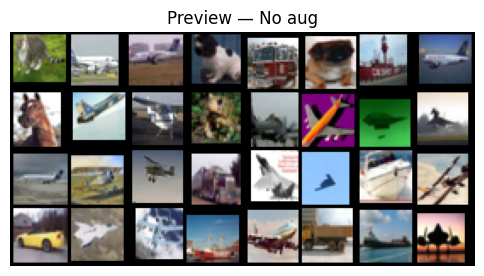

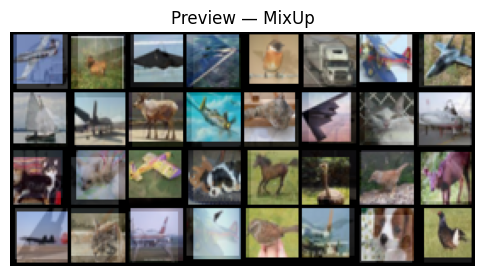

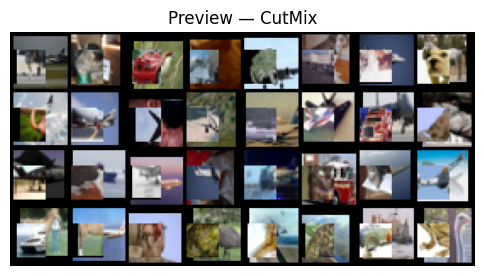

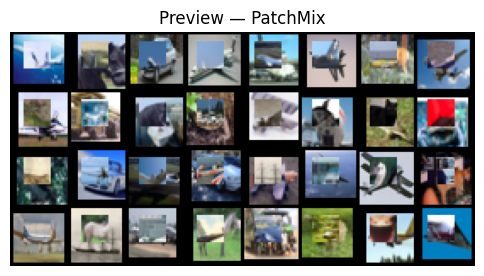

In [ ]:
# ====  DataLoaders (AS only) ====
def make_train_loader_as(dataset, indices, batch_size=128, num_workers=2):
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=True,
                      num_workers=num_workers, pin_memory=True)

pin = (device.type == "cuda")
test_loader = DataLoader(test_data, batch_size=256, shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=pin)

train_loader_as = make_train_loader_as(train_data, as_indices,
                                       batch_size=CONFIG["batch_size"],
                                       num_workers=CONFIG["num_workers"])

# Optional quick previews (won't affect training)
preview_one_batch(train_loader_as, "none")
preview_one_batch(train_loader_as, "mixup",    mixup_alpha=CONFIG["mixup_alpha"])
preview_one_batch(train_loader_as, "cutmix",   cutmix_alpha=CONFIG["cutmix_alpha"])
preview_one_batch(train_loader_as, "patchmix", patch_frac=CONFIG["patch_frac"])


In [ ]:
# ====  Train / Evaluate ====
def train_one_epoch_lace(model, loader, criterion_lace, opt,
                         use_mixup=False, use_cutmix=False, use_patchmix=False,
                         mixup_alpha=0.2, cutmix_alpha=0.5, patch_frac=0.5):
    model.train()
    tot_loss, corr, n = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)

        y2, lam = None, 1.0
        if use_cutmix:
            x, y, y2, lam = apply_cutmix(x, y, alpha=cutmix_alpha)
        elif use_mixup:
            x, y, y2, lam = apply_mixup(x, y, alpha=mixup_alpha)
        elif use_patchmix:
            x, y, y2, lam = apply_patchmix(x, y, patch_frac=patch_frac)

        logits = model(x)
        loss = criterion_lace(logits, y) if y2 is None else \
               lam * criterion_lace(logits, y) + (1-lam) * criterion_lace(logits, y2)

        opt.zero_grad(set_to_none=True)
        loss.backward(); opt.step()

        pred = logits.argmax(1)
        corr += (pred == y).sum().item()
        tot_loss += loss.item() * x.size(0)
        n += x.size(0)

    return tot_loss/n, corr/n

@torch.no_grad()
def evaluate_lace(model, loader, criterion_lace):
    model.eval()
    tot_loss, corr, n = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion_lace(logits, y)
        pred = logits.argmax(1)
        corr += (pred == y).sum().item()
        tot_loss += loss.item() * x.size(0)
        n += x.size(0)
    return tot_loss/n, corr/n

@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    ys, ps = [], []
    for x,y in loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(1).cpu().numpy()
        ys.append(y.numpy()); ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)

def confusion_matrix(y_true, y_pred, K=10):
    cm = np.zeros((K,K), dtype=np.int64)
    for t,p in zip(y_true, y_pred): cm[t,p]+=1
    return cm

def macro_f1(cm):
    prec = np.diag(cm) / np.clip(cm.sum(0), 1, None)
    rec  = np.diag(cm) / np.clip(cm.sum(1), 1, None)
    f1   = 2*prec*rec / np.clip(prec+rec, 1e-12, None)
    return float(np.nanmean(f1))

def balanced_acc(cm):
    rec  = np.diag(cm) / np.clip(cm.sum(1), 1, None)
    return float(np.nanmean(rec))



                 AS | Logit-Adjusted CE  (tau=0.5)

--- Augmentation: NONE ---

AS | resnet18 | tau=0.5 | aug=none
Ep 01 | train_loss=2.576 acc=47.6% | val_loss=2.892 acc=10.0%
Ep 05 | train_loss=1.450 acc=50.1% | val_loss=2.349 acc=18.9%
Ep 10 | train_loss=1.303 acc=52.4% | val_loss=2.145 acc=31.1%
Ep 15 | train_loss=1.088 acc=59.5% | val_loss=1.669 acc=44.1%
Ep 20 | train_loss=0.914 acc=66.2% | val_loss=1.418 acc=51.8%
Ep 25 | train_loss=0.736 acc=72.9% | val_loss=1.176 acc=61.2%
Ep 30 | train_loss=0.541 acc=79.8% | val_loss=1.212 acc=62.7%
Ep 35 | train_loss=0.398 acc=85.2% | val_loss=0.917 acc=71.2%
Ep 40 | train_loss=0.263 acc=90.5% | val_loss=1.006 acc=72.3%
Ep 45 | train_loss=0.166 acc=94.3% | val_loss=1.011 acc=73.3%
Ep 50 | train_loss=0.122 acc=96.0% | val_loss=0.969 acc=73.9%
Final test — Acc 74.22% | Macro-F1 74.04% | Balanced Acc 74.22%

--- Classification report: AS_resnet18_tau0.5_none ---
              precision    recall  f1-score   support

    airplane       0.69    

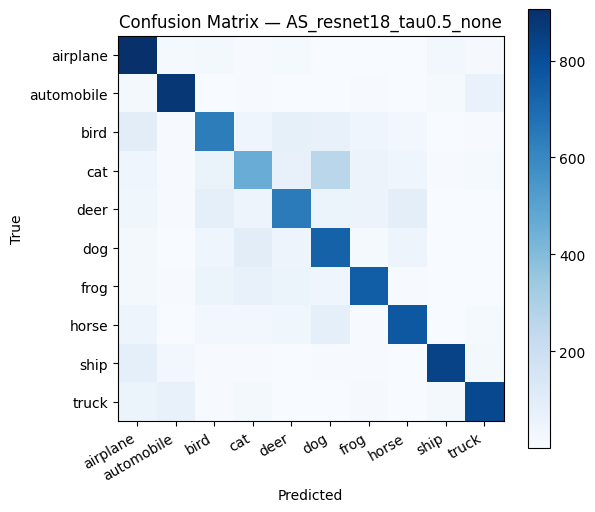

Saved: figures/cm_AS_resnet18_tau0.5_none.png


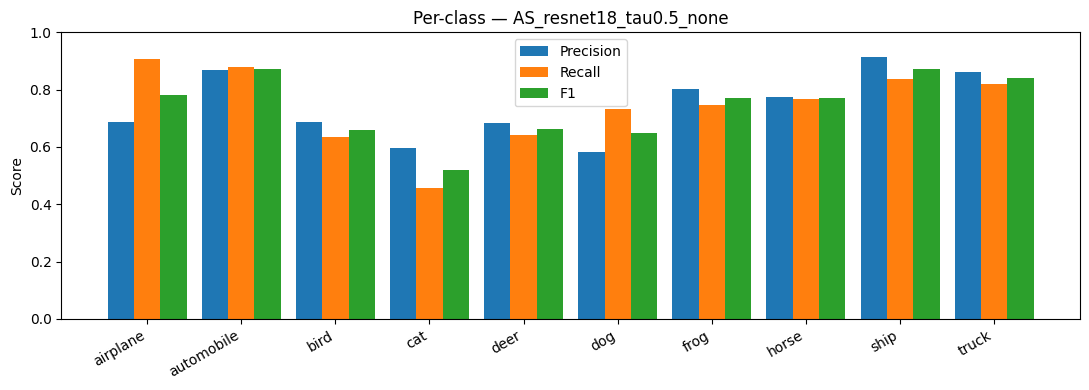

Saved: figures/perclass_AS_resnet18_tau0.5_none.png

AS | densenet121 | tau=0.5 | aug=none
Ep 01 | train_loss=1.848 acc=47.6% | val_loss=2.832 acc=16.5%
Ep 05 | train_loss=1.147 acc=58.1% | val_loss=1.834 acc=38.5%
Ep 10 | train_loss=0.882 acc=67.6% | val_loss=1.447 acc=52.6%
Ep 15 | train_loss=0.704 acc=73.9% | val_loss=1.416 acc=56.8%
Ep 20 | train_loss=0.550 acc=79.7% | val_loss=1.175 acc=63.4%
Ep 25 | train_loss=0.397 acc=85.5% | val_loss=1.511 acc=59.1%
Ep 30 | train_loss=0.241 acc=90.9% | val_loss=1.235 acc=67.5%
Ep 35 | train_loss=0.123 acc=95.5% | val_loss=1.147 acc=71.4%
Ep 40 | train_loss=0.044 acc=98.7% | val_loss=1.207 acc=73.5%
Ep 45 | train_loss=0.014 acc=99.7% | val_loss=1.253 acc=73.8%
Ep 50 | train_loss=0.011 acc=99.9% | val_loss=1.238 acc=74.3%
Final test — Acc 74.27% | Macro-F1 74.30% | Balanced Acc 74.27%

--- Classification report: AS_densenet121_tau0.5_none ---
              precision    recall  f1-score   support

    airplane       0.61      0.95      0.74      

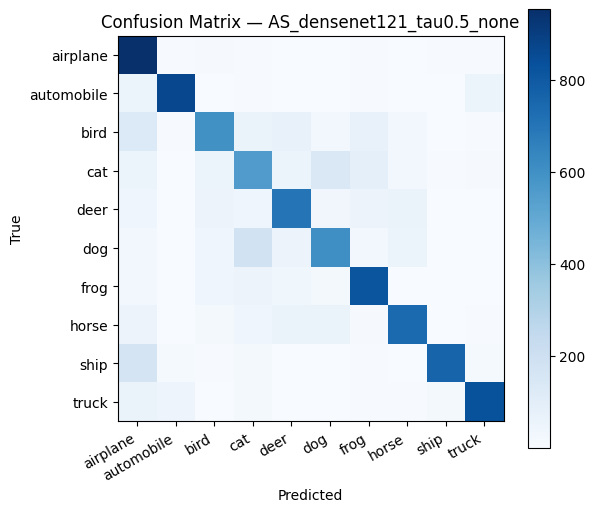

Saved: figures/cm_AS_densenet121_tau0.5_none.png


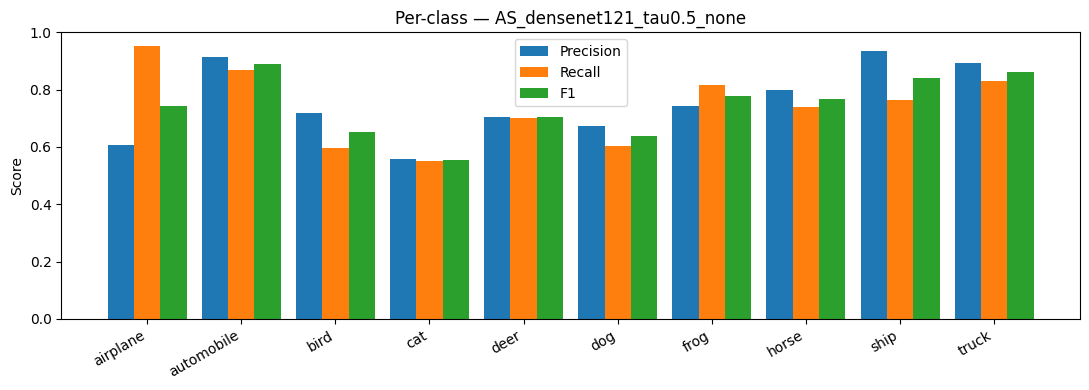

Saved: figures/perclass_AS_densenet121_tau0.5_none.png

--- Augmentation: MIXUP ---

AS | resnet18 | tau=0.5 | aug=mixup
Ep 01 | train_loss=2.335 acc=45.4% | val_loss=2.752 acc=16.7%
Ep 05 | train_loss=1.476 acc=43.9% | val_loss=2.273 acc=20.0%
Ep 10 | train_loss=1.315 acc=46.1% | val_loss=1.817 acc=37.8%
Ep 15 | train_loss=1.213 acc=46.8% | val_loss=1.710 acc=44.8%
Ep 20 | train_loss=1.060 acc=46.6% | val_loss=1.388 acc=53.2%
Ep 25 | train_loss=0.997 acc=51.5% | val_loss=1.470 acc=51.1%
Ep 30 | train_loss=0.853 acc=54.6% | val_loss=1.059 acc=65.3%
Ep 35 | train_loss=0.770 acc=55.4% | val_loss=0.973 acc=68.8%
Ep 40 | train_loss=0.622 acc=58.1% | val_loss=1.019 acc=69.5%
Ep 45 | train_loss=0.490 acc=65.5% | val_loss=0.880 acc=73.9%
Ep 50 | train_loss=0.550 acc=57.3% | val_loss=0.852 acc=74.3%
Final test — Acc 74.34% | Macro-F1 74.17% | Balanced Acc 74.34%

--- Classification report: AS_resnet18_tau0.5_mixup ---
              precision    recall  f1-score   support

    airplane       0.

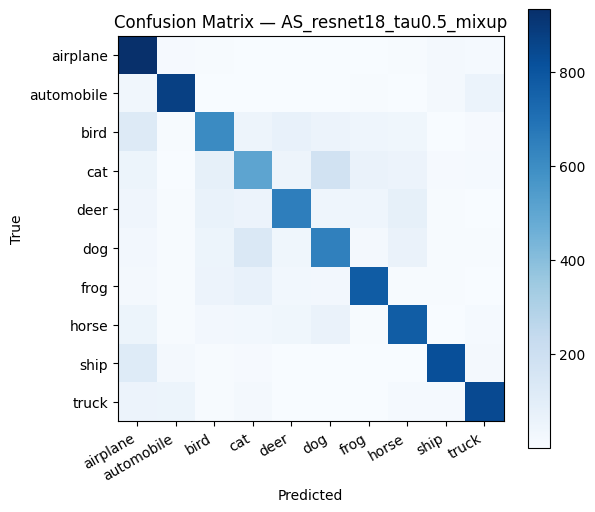

Saved: figures/cm_AS_resnet18_tau0.5_mixup.png


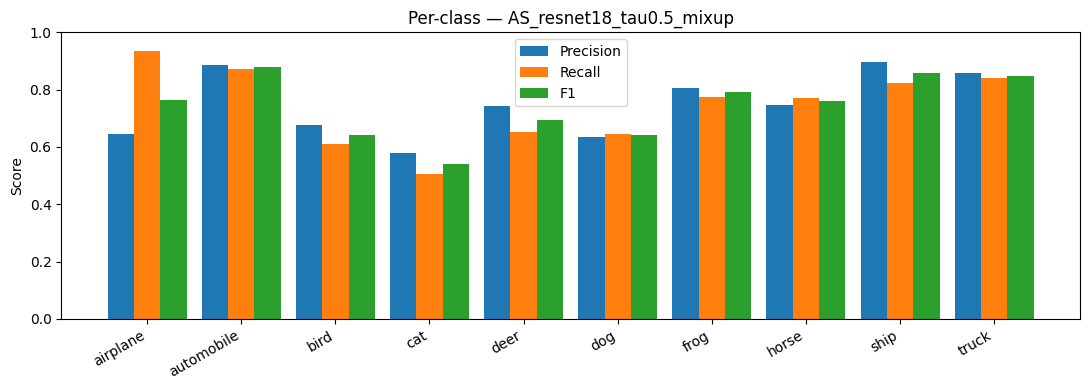

Saved: figures/perclass_AS_resnet18_tau0.5_mixup.png

AS | densenet121 | tau=0.5 | aug=mixup
Ep 01 | train_loss=1.859 acc=42.2% | val_loss=2.357 acc=19.6%
Ep 05 | train_loss=1.314 acc=43.5% | val_loss=1.807 acc=38.2%
Ep 10 | train_loss=1.160 acc=47.8% | val_loss=1.930 acc=40.3%
Ep 15 | train_loss=0.993 acc=49.9% | val_loss=1.452 acc=55.0%
Ep 20 | train_loss=0.860 acc=50.2% | val_loss=1.114 acc=63.6%
Ep 25 | train_loss=0.722 acc=56.0% | val_loss=1.003 acc=66.7%
Ep 30 | train_loss=0.782 acc=53.6% | val_loss=1.274 acc=62.6%
Ep 35 | train_loss=0.496 acc=62.3% | val_loss=0.993 acc=71.4%
Ep 40 | train_loss=0.548 acc=56.4% | val_loss=0.958 acc=72.2%
Ep 45 | train_loss=0.424 acc=62.3% | val_loss=0.857 acc=75.5%
Ep 50 | train_loss=0.394 acc=63.7% | val_loss=0.858 acc=75.6%
Final test — Acc 75.76% | Macro-F1 75.68% | Balanced Acc 75.76%

--- Classification report: AS_densenet121_tau0.5_mixup ---
              precision    recall  f1-score   support

    airplane       0.64      0.94      0.76   

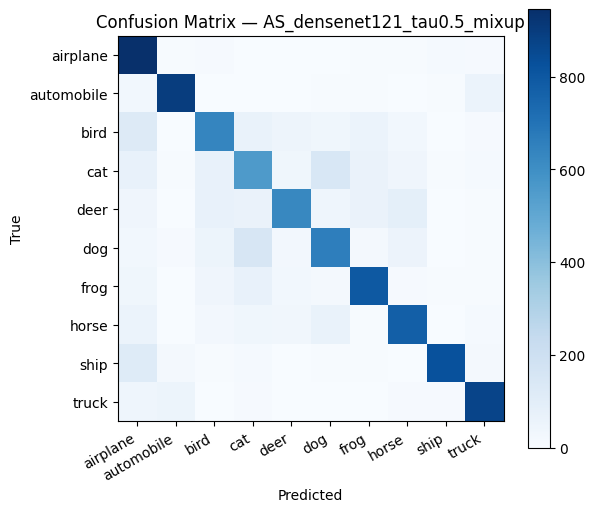

Saved: figures/cm_AS_densenet121_tau0.5_mixup.png


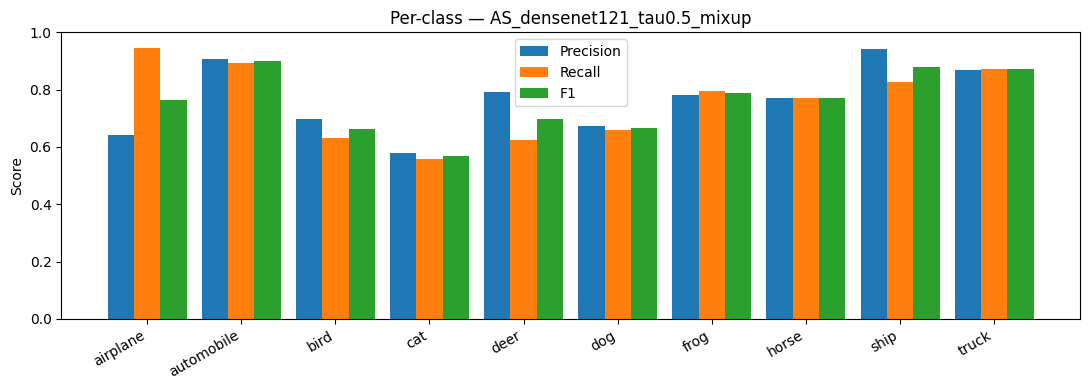

Saved: figures/perclass_AS_densenet121_tau0.5_mixup.png

--- Augmentation: CUTMIX ---

AS | resnet18 | tau=0.5 | aug=cutmix
Ep 01 | train_loss=2.206 acc=45.2% | val_loss=2.452 acc=17.4%
Ep 05 | train_loss=1.544 acc=49.2% | val_loss=2.047 acc=28.8%
Ep 10 | train_loss=1.425 acc=52.4% | val_loss=1.805 acc=38.4%
Ep 15 | train_loss=1.342 acc=53.1% | val_loss=1.638 acc=45.2%
Ep 20 | train_loss=1.256 acc=57.9% | val_loss=1.350 acc=55.3%
Ep 25 | train_loss=1.151 acc=61.4% | val_loss=1.492 acc=50.3%
Ep 30 | train_loss=1.029 acc=67.6% | val_loss=1.083 acc=65.6%
Ep 35 | train_loss=1.010 acc=65.3% | val_loss=0.989 acc=69.4%
Ep 40 | train_loss=1.022 acc=62.3% | val_loss=0.888 acc=73.4%
Ep 45 | train_loss=0.932 acc=68.0% | val_loss=0.779 acc=76.3%
Ep 50 | train_loss=0.929 acc=69.2% | val_loss=0.803 acc=76.4%
Final test — Acc 76.95% | Macro-F1 76.85% | Balanced Acc 76.95%

--- Classification report: AS_resnet18_tau0.5_cutmix ---
              precision    recall  f1-score   support

    airplane     

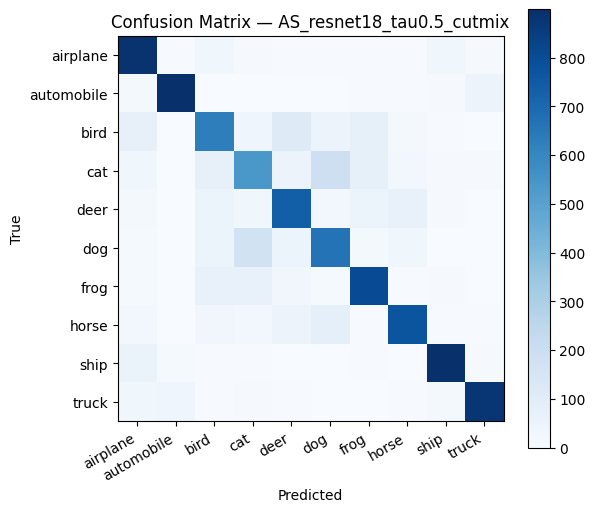

Saved: figures/cm_AS_resnet18_tau0.5_cutmix.png


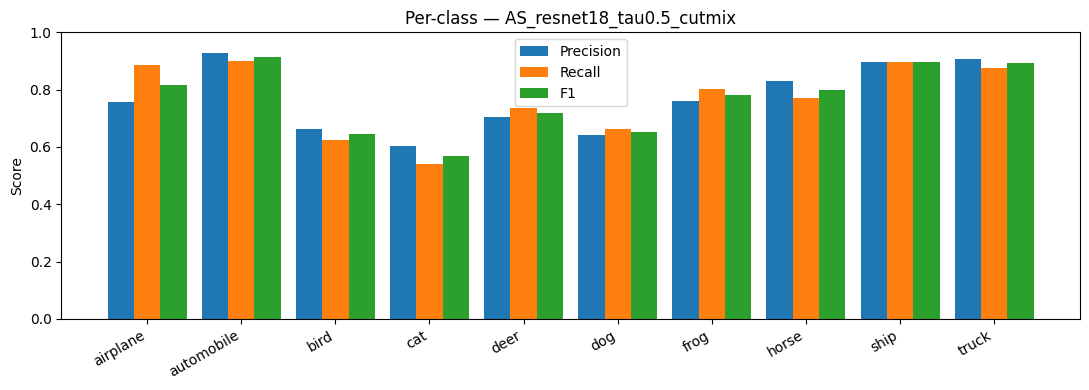

Saved: figures/perclass_AS_resnet18_tau0.5_cutmix.png

AS | densenet121 | tau=0.5 | aug=cutmix
Ep 01 | train_loss=1.851 acc=44.9% | val_loss=2.423 acc=18.8%
Ep 05 | train_loss=1.437 acc=50.4% | val_loss=1.923 acc=34.4%
Ep 10 | train_loss=1.354 acc=51.5% | val_loss=1.638 acc=45.7%
Ep 15 | train_loss=1.206 acc=58.4% | val_loss=1.558 acc=48.7%
Ep 20 | train_loss=1.133 acc=59.9% | val_loss=1.615 acc=51.4%
Ep 25 | train_loss=1.099 acc=61.0% | val_loss=1.340 acc=58.6%
Ep 30 | train_loss=0.938 acc=69.2% | val_loss=0.937 acc=69.2%
Ep 35 | train_loss=0.914 acc=69.5% | val_loss=0.936 acc=71.0%
Ep 40 | train_loss=0.855 acc=68.5% | val_loss=0.811 acc=75.9%
Ep 45 | train_loss=0.793 acc=71.9% | val_loss=0.793 acc=77.1%
Ep 50 | train_loss=0.766 acc=75.7% | val_loss=0.762 acc=77.8%
Final test — Acc 77.83% | Macro-F1 77.67% | Balanced Acc 77.83%

--- Classification report: AS_densenet121_tau0.5_cutmix ---
              precision    recall  f1-score   support

    airplane       0.72      0.92      0.81

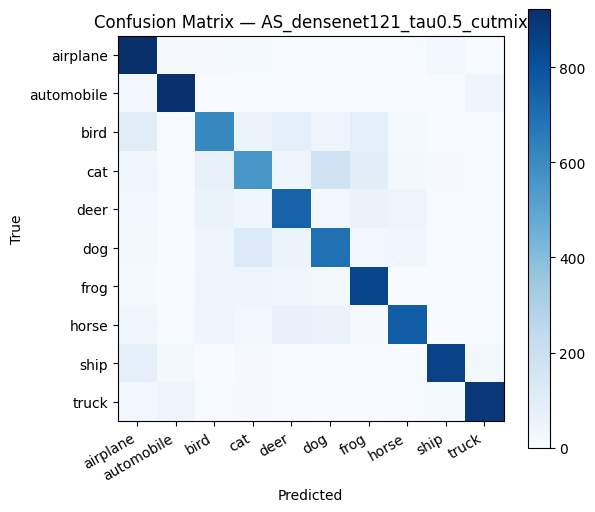

Saved: figures/cm_AS_densenet121_tau0.5_cutmix.png


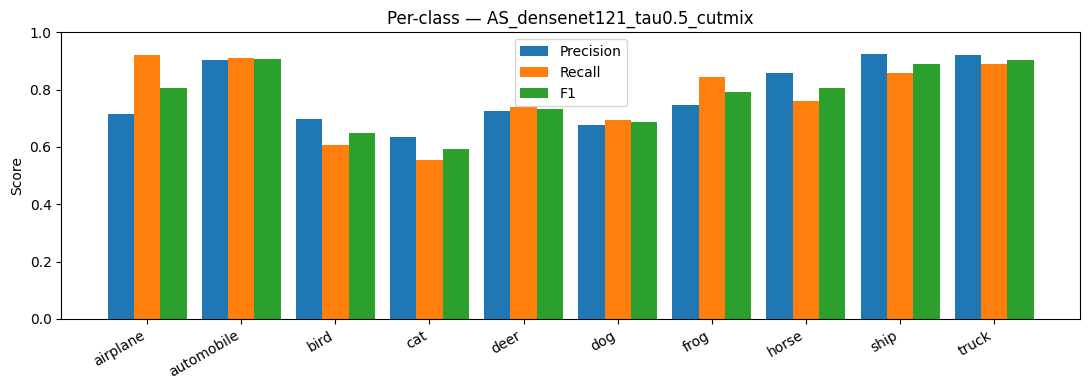

Saved: figures/perclass_AS_densenet121_tau0.5_cutmix.png

--- Augmentation: PATCHMIX ---

AS | resnet18 | tau=0.5 | aug=patchmix
Ep 01 | train_loss=2.301 acc=47.1% | val_loss=2.585 acc=10.0%
Ep 05 | train_loss=1.624 acc=52.2% | val_loss=2.338 acc=17.6%
Ep 10 | train_loss=1.569 acc=51.9% | val_loss=2.122 acc=24.5%
Ep 15 | train_loss=1.541 acc=52.5% | val_loss=2.020 acc=31.4%
Ep 20 | train_loss=1.502 acc=53.5% | val_loss=1.967 acc=31.5%
Ep 25 | train_loss=1.458 acc=52.6% | val_loss=1.749 acc=40.5%
Ep 30 | train_loss=1.412 acc=54.5% | val_loss=1.720 acc=45.0%
Ep 35 | train_loss=1.361 acc=56.6% | val_loss=1.561 acc=49.2%
Ep 40 | train_loss=1.321 acc=57.4% | val_loss=1.244 acc=61.3%
Ep 45 | train_loss=1.287 acc=58.8% | val_loss=1.252 acc=63.1%
Ep 50 | train_loss=1.266 acc=58.9% | val_loss=1.197 acc=64.9%
Final test — Acc 64.92% | Macro-F1 64.19% | Balanced Acc 64.92%

--- Classification report: AS_resnet18_tau0.5_patchmix ---
              precision    recall  f1-score   support

    airpla

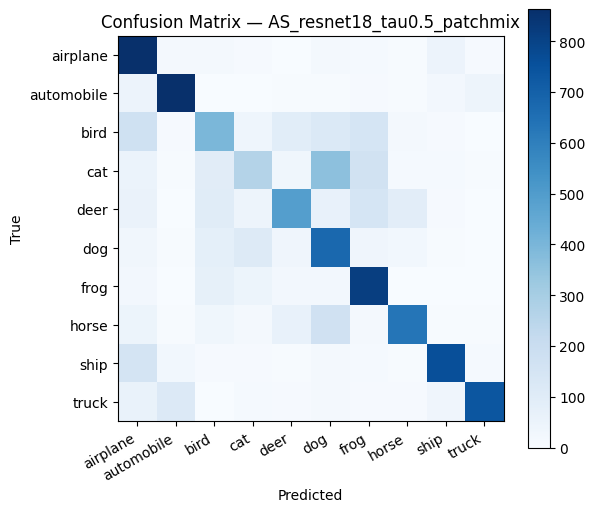

Saved: figures/cm_AS_resnet18_tau0.5_patchmix.png


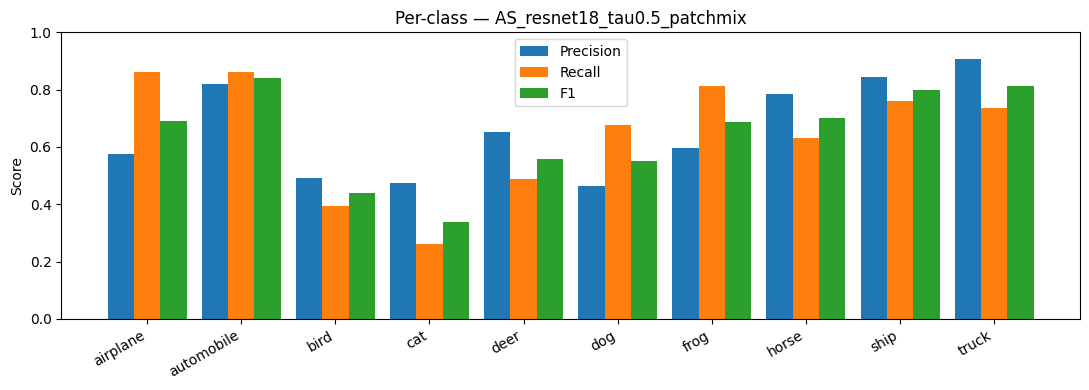

Saved: figures/perclass_AS_resnet18_tau0.5_patchmix.png

AS | densenet121 | tau=0.5 | aug=patchmix
Ep 01 | train_loss=1.883 acc=46.0% | val_loss=2.506 acc=16.6%
Ep 05 | train_loss=1.561 acc=53.0% | val_loss=2.095 acc=28.4%
Ep 10 | train_loss=1.491 acc=53.2% | val_loss=1.889 acc=39.8%
Ep 15 | train_loss=1.434 acc=55.0% | val_loss=1.532 acc=50.1%
Ep 20 | train_loss=1.373 acc=56.9% | val_loss=1.373 acc=55.2%
Ep 25 | train_loss=1.318 acc=56.5% | val_loss=1.346 acc=60.2%
Ep 30 | train_loss=1.255 acc=58.3% | val_loss=1.165 acc=63.1%
Ep 35 | train_loss=1.193 acc=60.6% | val_loss=1.119 acc=69.8%
Ep 40 | train_loss=1.129 acc=60.1% | val_loss=0.981 acc=71.2%
Ep 45 | train_loss=1.077 acc=62.7% | val_loss=0.943 acc=74.0%
Ep 50 | train_loss=1.048 acc=62.9% | val_loss=0.885 acc=76.3%
Final test — Acc 76.30% | Macro-F1 75.98% | Balanced Acc 76.30%

--- Classification report: AS_densenet121_tau0.5_patchmix ---
              precision    recall  f1-score   support

    airplane       0.73      0.88    

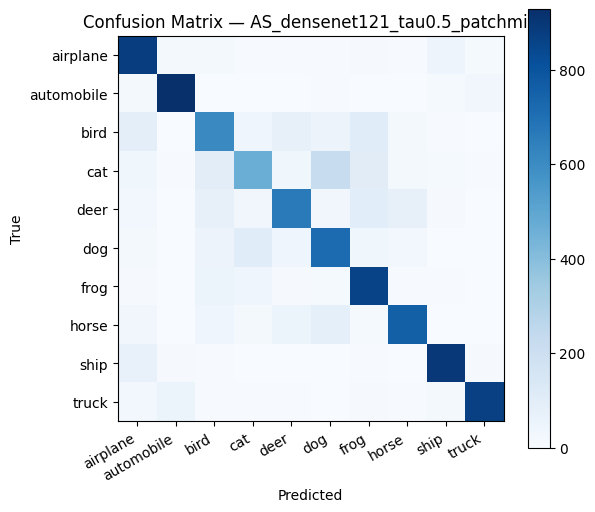

Saved: figures/cm_AS_densenet121_tau0.5_patchmix.png


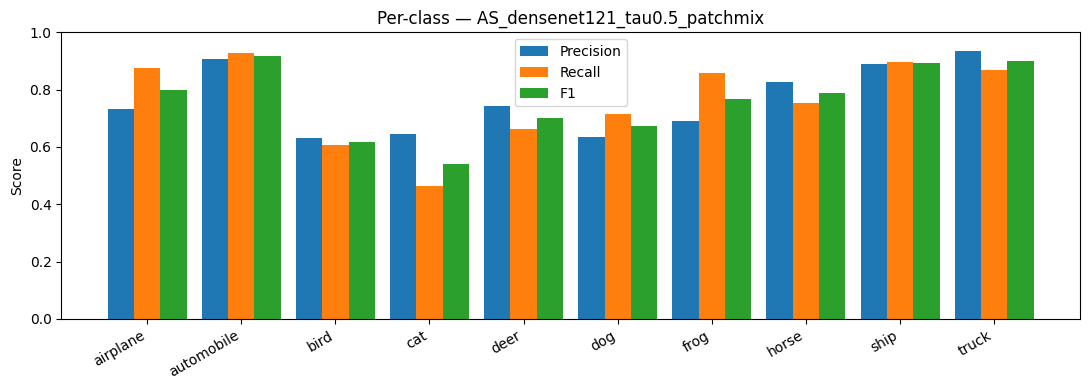

Saved: figures/perclass_AS_densenet121_tau0.5_patchmix.png

                 AS | Logit-Adjusted CE  (tau=1.0)

--- Augmentation: NONE ---

AS | resnet18 | tau=1.0 | aug=none
Ep 01 | train_loss=2.313 acc=22.7% | val_loss=2.399 acc=19.0%
Ep 05 | train_loss=1.278 acc=35.5% | val_loss=2.192 acc=30.3%
Ep 10 | train_loss=1.099 acc=47.7% | val_loss=1.672 acc=45.2%
Ep 15 | train_loss=0.930 acc=57.1% | val_loss=1.653 acc=49.9%
Ep 20 | train_loss=0.763 acc=66.5% | val_loss=1.361 acc=56.5%
Ep 25 | train_loss=0.610 acc=72.7% | val_loss=1.311 acc=62.3%
Ep 30 | train_loss=0.466 acc=79.2% | val_loss=1.104 acc=68.3%
Ep 35 | train_loss=0.326 acc=85.3% | val_loss=0.990 acc=71.5%
Ep 40 | train_loss=0.183 acc=91.4% | val_loss=1.149 acc=71.9%
Ep 45 | train_loss=0.099 acc=95.4% | val_loss=1.088 acc=73.7%
Ep 50 | train_loss=0.072 acc=97.0% | val_loss=1.080 acc=73.8%
Final test — Acc 73.94% | Macro-F1 73.79% | Balanced Acc 73.94%

--- Classification report: AS_resnet18_tau1.0_none ---
              precision

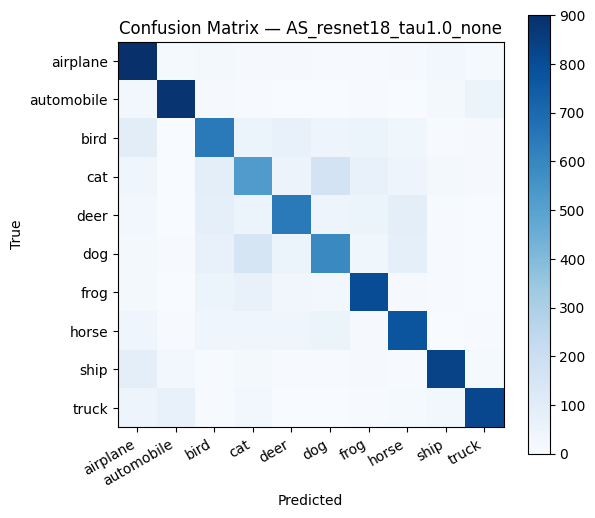

Saved: figures/cm_AS_resnet18_tau1.0_none.png


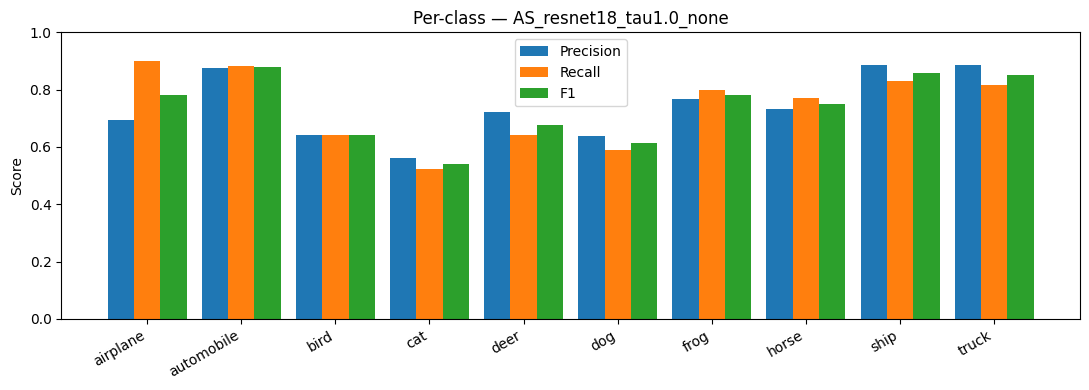

Saved: figures/perclass_AS_resnet18_tau1.0_none.png

AS | densenet121 | tau=1.0 | aug=none
Ep 01 | train_loss=1.672 acc=31.6% | val_loss=2.468 acc=21.4%
Ep 05 | train_loss=1.162 acc=45.7% | val_loss=2.044 acc=41.8%
Ep 10 | train_loss=0.886 acc=60.2% | val_loss=1.409 acc=48.7%
Ep 15 | train_loss=0.698 acc=69.5% | val_loss=1.318 acc=58.4%
Ep 20 | train_loss=0.515 acc=77.5% | val_loss=1.331 acc=63.9%
Ep 25 | train_loss=0.401 acc=82.3% | val_loss=1.100 acc=67.0%
Ep 30 | train_loss=0.242 acc=89.3% | val_loss=1.156 acc=68.1%
Ep 35 | train_loss=0.122 acc=94.4% | val_loss=1.197 acc=72.8%
Ep 40 | train_loss=0.042 acc=98.2% | val_loss=1.187 acc=74.5%
Ep 45 | train_loss=0.011 acc=99.6% | val_loss=1.184 acc=75.5%
Ep 50 | train_loss=0.011 acc=99.7% | val_loss=1.202 acc=75.5%
Final test — Acc 75.60% | Macro-F1 75.51% | Balanced Acc 75.60%

--- Classification report: AS_densenet121_tau1.0_none ---
              precision    recall  f1-score   support

    airplane       0.68      0.93      0.79      

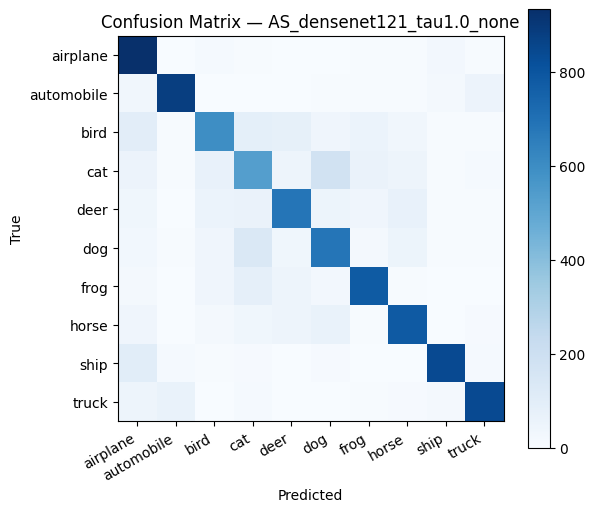

Saved: figures/cm_AS_densenet121_tau1.0_none.png


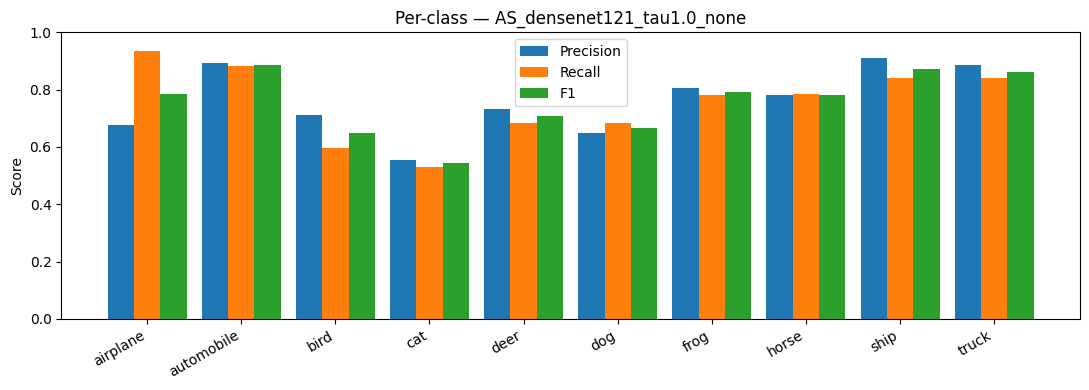

Saved: figures/perclass_AS_densenet121_tau1.0_none.png

--- Augmentation: MIXUP ---

AS | resnet18 | tau=1.0 | aug=mixup
Ep 01 | train_loss=2.353 acc=20.1% | val_loss=2.488 acc=20.5%
Ep 05 | train_loss=1.391 acc=27.6% | val_loss=2.039 acc=35.4%
Ep 10 | train_loss=1.238 acc=35.9% | val_loss=1.827 acc=44.6%
Ep 15 | train_loss=1.076 acc=39.6% | val_loss=1.788 acc=50.2%
Ep 20 | train_loss=0.934 acc=42.7% | val_loss=1.856 acc=53.0%
Ep 25 | train_loss=0.813 acc=48.7% | val_loss=1.095 acc=64.9%
Ep 30 | train_loss=0.772 acc=50.6% | val_loss=1.078 acc=67.3%
Ep 35 | train_loss=0.677 acc=51.7% | val_loss=0.919 acc=71.4%
Ep 40 | train_loss=0.565 acc=52.9% | val_loss=0.874 acc=73.8%
Ep 45 | train_loss=0.547 acc=56.1% | val_loss=0.873 acc=75.3%
Ep 50 | train_loss=0.434 acc=58.6% | val_loss=0.829 acc=75.9%
Final test — Acc 76.30% | Macro-F1 76.13% | Balanced Acc 76.30%

--- Classification report: AS_resnet18_tau1.0_mixup ---
              precision    recall  f1-score   support

    airplane       0.

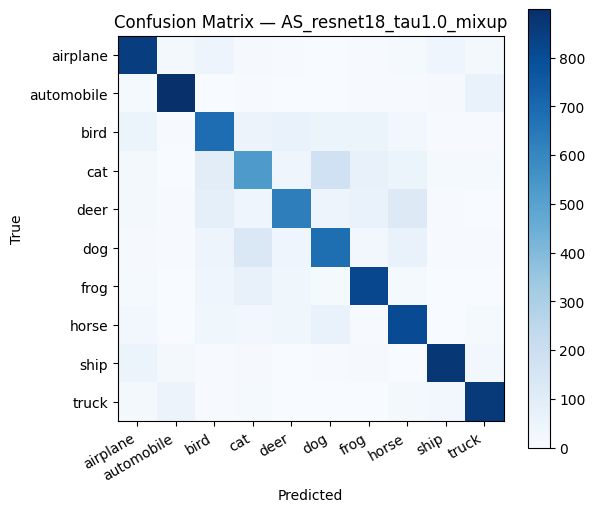

Saved: figures/cm_AS_resnet18_tau1.0_mixup.png


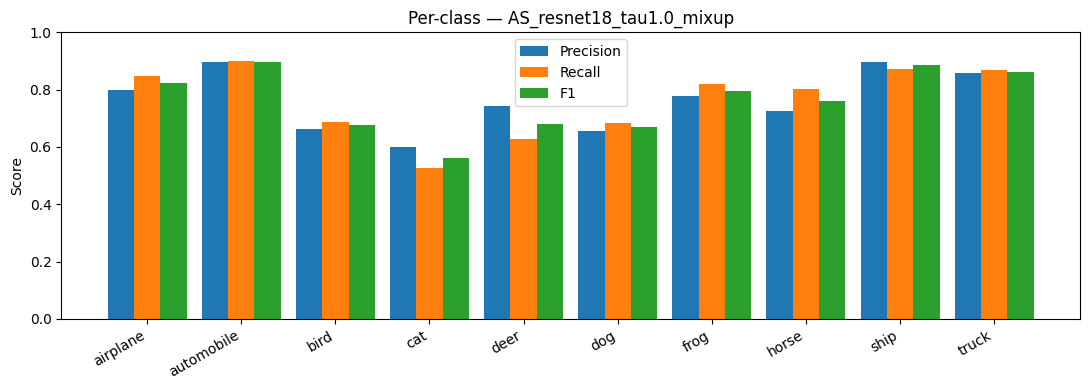

Saved: figures/perclass_AS_resnet18_tau1.0_mixup.png

AS | densenet121 | tau=1.0 | aug=mixup
Ep 01 | train_loss=1.701 acc=23.9% | val_loss=3.602 acc=19.9%
Ep 05 | train_loss=1.303 acc=30.5% | val_loss=1.916 acc=41.8%
Ep 10 | train_loss=1.169 acc=38.4% | val_loss=1.593 acc=49.4%
Ep 15 | train_loss=0.925 acc=45.8% | val_loss=1.480 acc=56.9%
Ep 20 | train_loss=0.785 acc=50.8% | val_loss=1.126 acc=64.3%
Ep 25 | train_loss=0.792 acc=48.8% | val_loss=1.217 acc=67.2%
Ep 30 | train_loss=0.596 acc=50.1% | val_loss=1.154 acc=68.8%
Ep 35 | train_loss=0.566 acc=53.6% | val_loss=1.063 acc=70.7%
Ep 40 | train_loss=0.479 acc=59.9% | val_loss=0.851 acc=75.6%
Ep 45 | train_loss=0.442 acc=59.3% | val_loss=0.902 acc=76.0%
Ep 50 | train_loss=0.310 acc=63.1% | val_loss=0.861 acc=77.5%
Final test — Acc 77.47% | Macro-F1 77.40% | Balanced Acc 77.47%

--- Classification report: AS_densenet121_tau1.0_mixup ---
              precision    recall  f1-score   support

    airplane       0.73      0.92      0.82   

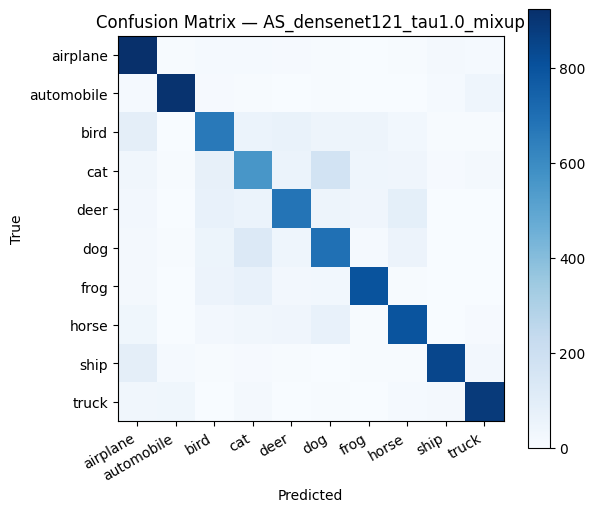

Saved: figures/cm_AS_densenet121_tau1.0_mixup.png


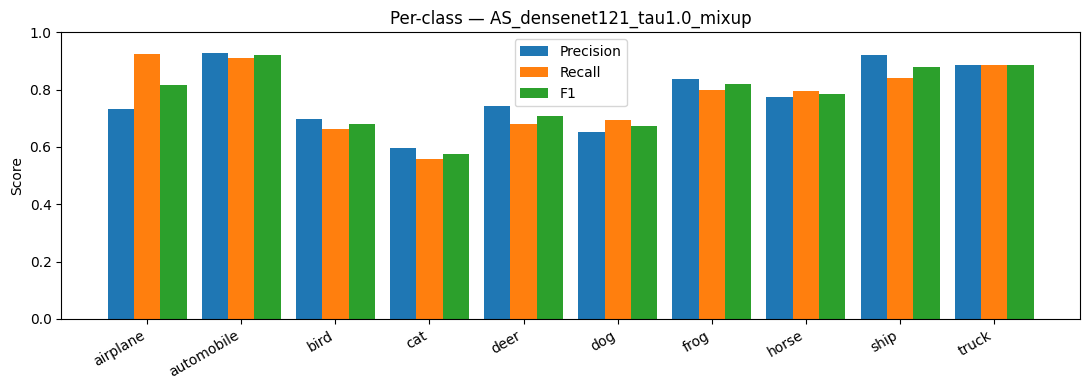

Saved: figures/perclass_AS_densenet121_tau1.0_mixup.png

--- Augmentation: CUTMIX ---

AS | resnet18 | tau=1.0 | aug=cutmix
Ep 01 | train_loss=2.299 acc=19.1% | val_loss=2.513 acc=14.2%
Ep 05 | train_loss=1.541 acc=27.6% | val_loss=2.164 acc=31.2%
Ep 10 | train_loss=1.424 acc=31.8% | val_loss=1.986 acc=39.5%
Ep 15 | train_loss=1.370 acc=38.2% | val_loss=1.628 acc=43.1%
Ep 20 | train_loss=1.293 acc=42.7% | val_loss=1.658 acc=49.4%
Ep 25 | train_loss=1.188 acc=49.2% | val_loss=1.553 acc=51.1%
Ep 30 | train_loss=1.156 acc=47.7% | val_loss=1.408 acc=56.3%
Ep 35 | train_loss=1.103 acc=54.4% | val_loss=1.207 acc=63.1%
Ep 40 | train_loss=0.998 acc=57.2% | val_loss=1.034 acc=68.7%
Ep 45 | train_loss=0.980 acc=59.4% | val_loss=0.976 acc=69.6%
Ep 50 | train_loss=0.909 acc=60.7% | val_loss=0.946 acc=71.6%
Final test — Acc 71.58% | Macro-F1 71.40% | Balanced Acc 71.58%

--- Classification report: AS_resnet18_tau1.0_cutmix ---
              precision    recall  f1-score   support

    airplane     

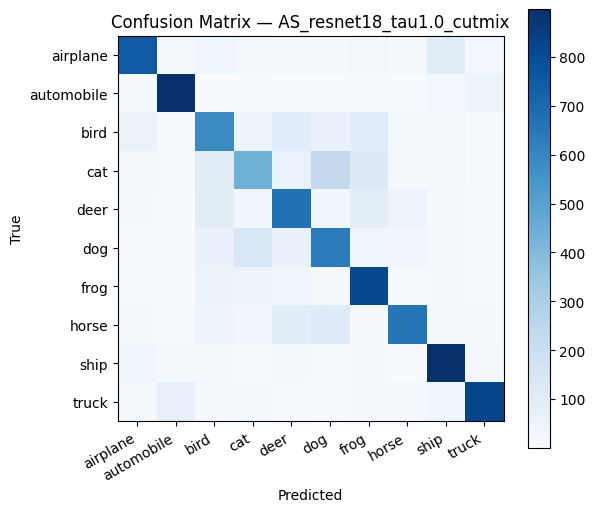

Saved: figures/cm_AS_resnet18_tau1.0_cutmix.png


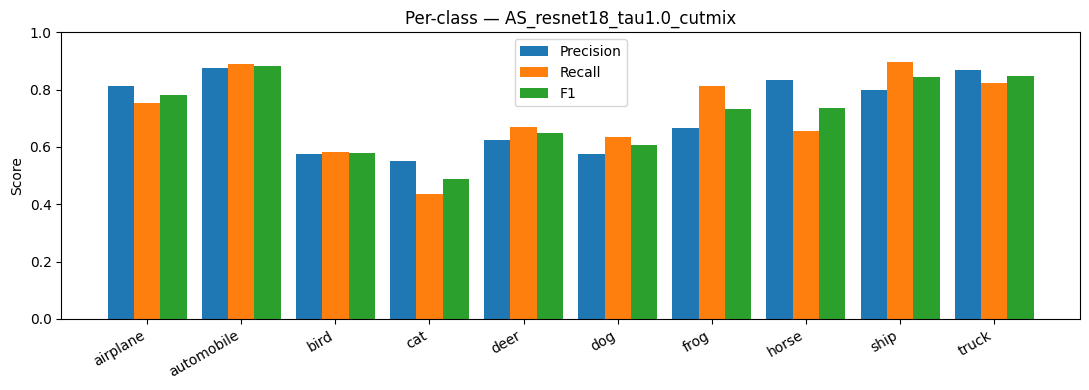

Saved: figures/perclass_AS_resnet18_tau1.0_cutmix.png

AS | densenet121 | tau=1.0 | aug=cutmix
Ep 01 | train_loss=2.021 acc=23.5% | val_loss=2.965 acc=20.1%
Ep 05 | train_loss=1.488 acc=32.2% | val_loss=2.042 acc=30.8%
Ep 10 | train_loss=1.358 acc=38.5% | val_loss=1.796 acc=43.6%
Ep 15 | train_loss=1.222 acc=46.4% | val_loss=1.476 acc=52.0%
Ep 20 | train_loss=1.176 acc=48.8% | val_loss=1.542 acc=54.7%
Ep 25 | train_loss=1.133 acc=51.5% | val_loss=1.271 acc=62.1%
Ep 30 | train_loss=1.043 acc=55.1% | val_loss=1.059 acc=66.4%
Ep 35 | train_loss=0.936 acc=61.2% | val_loss=1.044 acc=68.2%
Ep 40 | train_loss=0.879 acc=63.6% | val_loss=0.917 acc=72.8%
Ep 45 | train_loss=0.847 acc=62.9% | val_loss=0.827 acc=75.6%
Ep 50 | train_loss=0.760 acc=68.9% | val_loss=0.807 acc=76.5%
Final test — Acc 76.50% | Macro-F1 76.51% | Balanced Acc 76.50%

--- Classification report: AS_densenet121_tau1.0_cutmix ---
              precision    recall  f1-score   support

    airplane       0.81      0.81      0.81

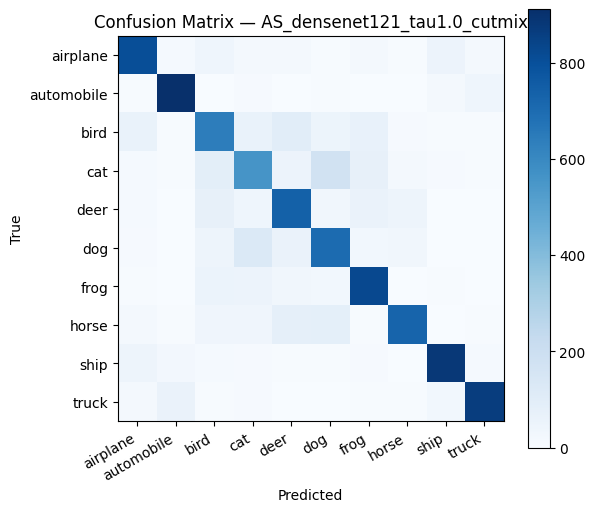

Saved: figures/cm_AS_densenet121_tau1.0_cutmix.png


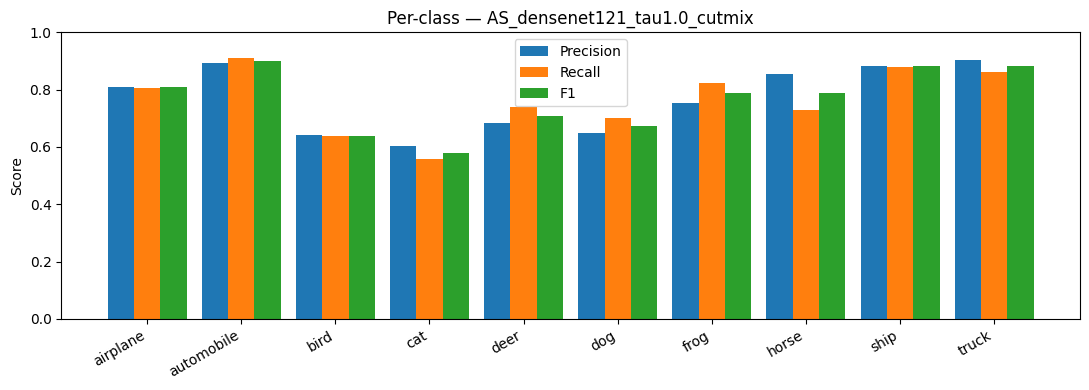

Saved: figures/perclass_AS_densenet121_tau1.0_cutmix.png

--- Augmentation: PATCHMIX ---

AS | resnet18 | tau=1.0 | aug=patchmix
Ep 01 | train_loss=2.450 acc=16.9% | val_loss=2.741 acc=13.4%
Ep 05 | train_loss=1.628 acc=22.2% | val_loss=2.301 acc=23.4%
Ep 10 | train_loss=1.576 acc=25.5% | val_loss=2.158 acc=28.0%
Ep 15 | train_loss=1.542 acc=26.6% | val_loss=2.069 acc=36.2%
Ep 20 | train_loss=1.514 acc=29.9% | val_loss=1.845 acc=39.3%
Ep 25 | train_loss=1.478 acc=31.1% | val_loss=1.844 acc=40.8%
Ep 30 | train_loss=1.440 acc=36.7% | val_loss=1.763 acc=41.8%
Ep 35 | train_loss=1.399 acc=38.1% | val_loss=1.513 acc=49.4%
Ep 40 | train_loss=1.364 acc=38.5% | val_loss=1.355 acc=56.7%
Ep 45 | train_loss=1.326 acc=43.0% | val_loss=1.337 acc=59.3%
Ep 50 | train_loss=1.309 acc=43.1% | val_loss=1.279 acc=62.2%
Final test — Acc 62.18% | Macro-F1 61.35% | Balanced Acc 62.18%

--- Classification report: AS_resnet18_tau1.0_patchmix ---
              precision    recall  f1-score   support

    airpla

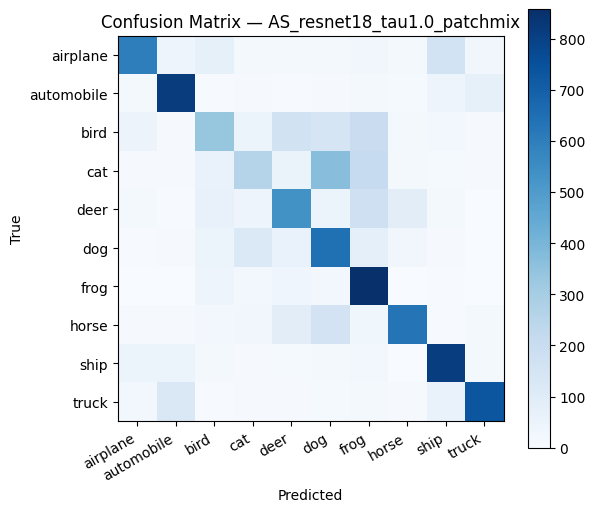

Saved: figures/cm_AS_resnet18_tau1.0_patchmix.png


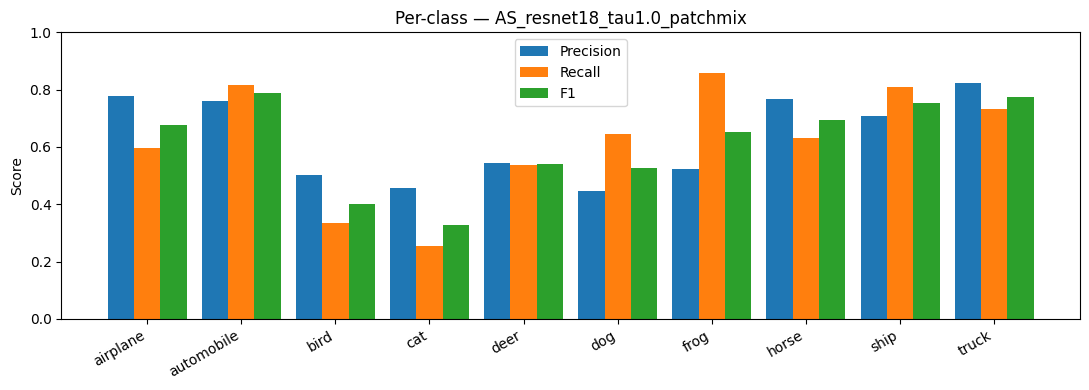

Saved: figures/perclass_AS_resnet18_tau1.0_patchmix.png

AS | densenet121 | tau=1.0 | aug=patchmix
Ep 01 | train_loss=1.818 acc=23.0% | val_loss=2.193 acc=23.9%
Ep 05 | train_loss=1.540 acc=30.0% | val_loss=2.049 acc=38.4%
Ep 10 | train_loss=1.481 acc=35.9% | val_loss=2.083 acc=37.3%
Ep 15 | train_loss=1.416 acc=38.2% | val_loss=1.592 acc=52.3%
Ep 20 | train_loss=1.363 acc=39.9% | val_loss=1.652 acc=51.6%
Ep 25 | train_loss=1.307 acc=41.7% | val_loss=1.446 acc=57.4%
Ep 30 | train_loss=1.261 acc=45.9% | val_loss=1.265 acc=58.0%
Ep 35 | train_loss=1.194 acc=46.5% | val_loss=1.169 acc=66.9%
Ep 40 | train_loss=1.130 acc=49.5% | val_loss=0.981 acc=69.6%
Ep 45 | train_loss=1.086 acc=51.3% | val_loss=0.924 acc=74.1%
Ep 50 | train_loss=1.058 acc=51.8% | val_loss=0.895 acc=75.3%
Final test — Acc 75.30% | Macro-F1 75.13% | Balanced Acc 75.30%

--- Classification report: AS_densenet121_tau1.0_patchmix ---
              precision    recall  f1-score   support

    airplane       0.90      0.71    

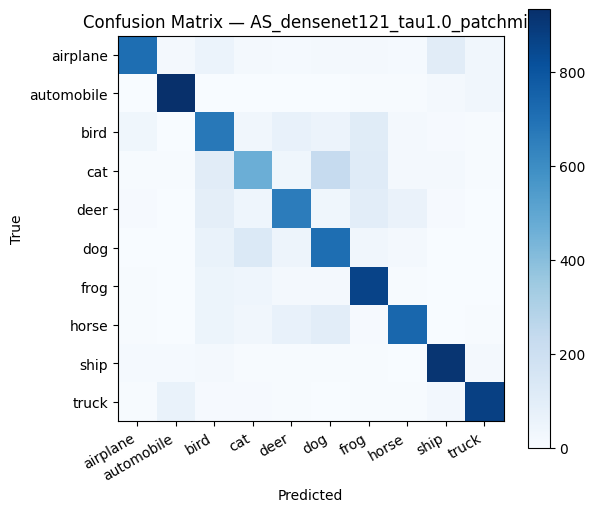

Saved: figures/cm_AS_densenet121_tau1.0_patchmix.png


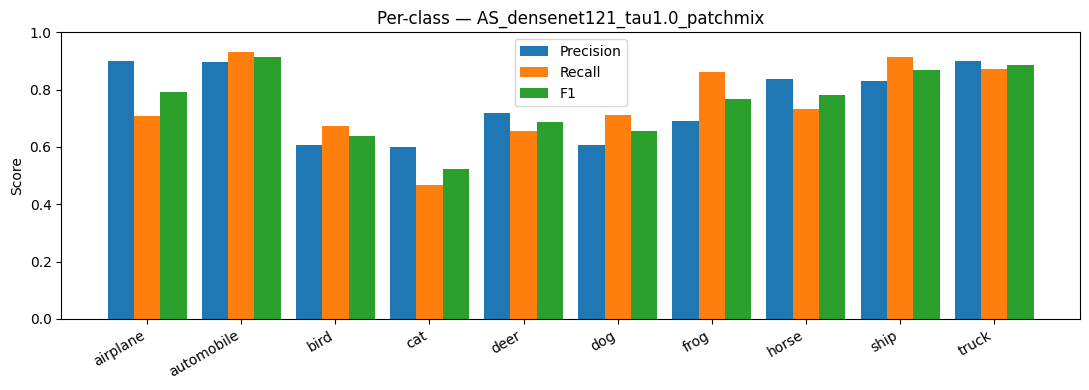

Saved: figures/perclass_AS_densenet121_tau1.0_patchmix.png

                 AS | Logit-Adjusted CE  (tau=2.0)

--- Augmentation: NONE ---

AS | resnet18 | tau=2.0 | aug=none
Ep 01 | train_loss=2.185 acc=12.4% | val_loss=3.134 acc=17.1%
Ep 05 | train_loss=1.262 acc=17.7% | val_loss=1.999 acc=35.1%
Ep 10 | train_loss=1.074 acc=25.0% | val_loss=1.634 acc=37.3%
Ep 15 | train_loss=0.915 acc=35.9% | val_loss=1.384 acc=51.9%
Ep 20 | train_loss=0.736 acc=47.8% | val_loss=1.290 acc=57.0%
Ep 25 | train_loss=0.569 acc=59.3% | val_loss=1.057 acc=66.1%
Ep 30 | train_loss=0.442 acc=67.9% | val_loss=1.034 acc=68.1%
Ep 35 | train_loss=0.295 acc=76.4% | val_loss=1.212 acc=71.5%
Ep 40 | train_loss=0.182 acc=83.9% | val_loss=0.913 acc=74.3%
Ep 45 | train_loss=0.101 acc=89.2% | val_loss=0.977 acc=75.3%
Ep 50 | train_loss=0.075 acc=90.8% | val_loss=0.979 acc=76.3%
Final test — Acc 76.34% | Macro-F1 76.31% | Balanced Acc 76.34%

--- Classification report: AS_resnet18_tau2.0_none ---
              precision

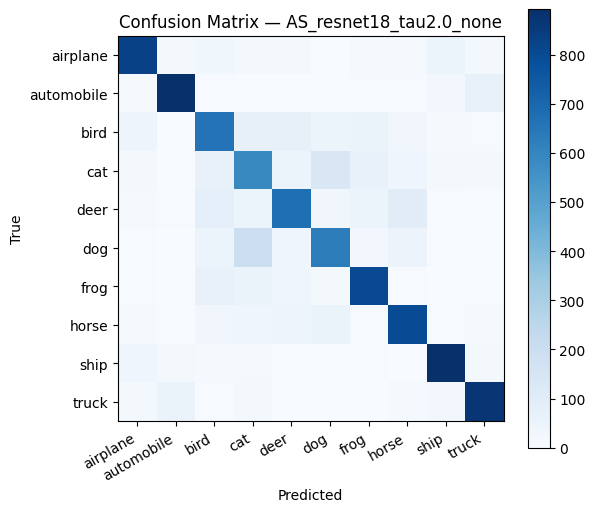

Saved: figures/cm_AS_resnet18_tau2.0_none.png


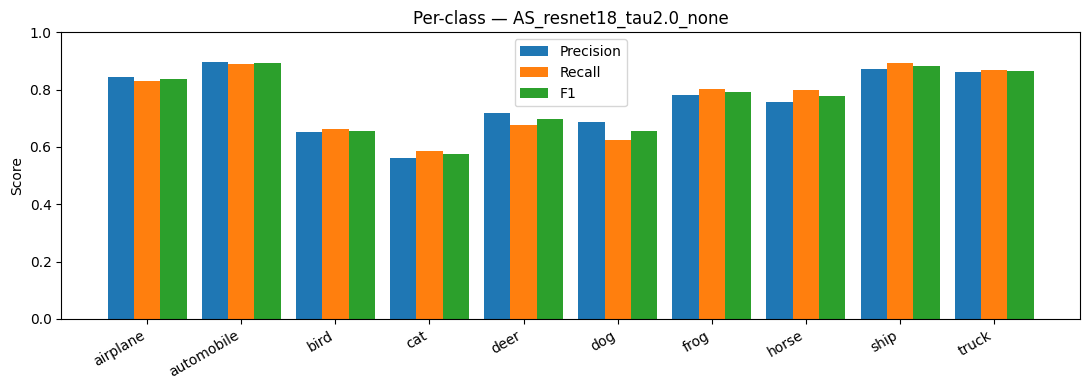

Saved: figures/perclass_AS_resnet18_tau2.0_none.png

AS | densenet121 | tau=2.0 | aug=none
Ep 01 | train_loss=1.719 acc=15.7% | val_loss=57.251 acc=14.8%
Ep 05 | train_loss=1.095 acc=26.1% | val_loss=1.694 acc=42.3%
Ep 10 | train_loss=0.833 acc=42.8% | val_loss=1.640 acc=47.6%
Ep 15 | train_loss=0.626 acc=55.0% | val_loss=1.445 acc=60.6%
Ep 20 | train_loss=0.508 acc=63.3% | val_loss=1.062 acc=63.4%
Ep 25 | train_loss=0.342 acc=73.1% | val_loss=1.339 acc=64.6%
Ep 30 | train_loss=0.210 acc=82.5% | val_loss=1.074 acc=70.2%
Ep 35 | train_loss=0.097 acc=89.9% | val_loss=1.305 acc=72.3%
Ep 40 | train_loss=0.025 acc=96.0% | val_loss=1.223 acc=75.7%
Ep 45 | train_loss=0.012 acc=97.1% | val_loss=1.203 acc=76.4%
Ep 50 | train_loss=0.009 acc=97.8% | val_loss=1.222 acc=76.3%
Final test — Acc 76.51% | Macro-F1 76.45% | Balanced Acc 76.51%

--- Classification report: AS_densenet121_tau2.0_none ---
              precision    recall  f1-score   support

    airplane       0.80      0.86      0.83     

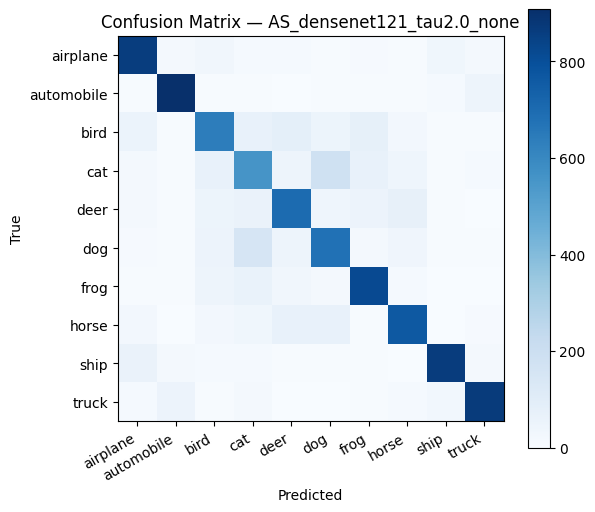

Saved: figures/cm_AS_densenet121_tau2.0_none.png


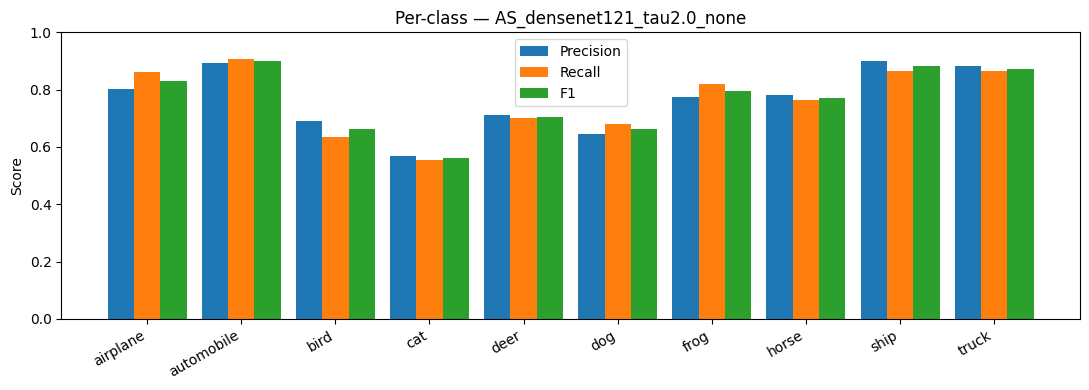

Saved: figures/perclass_AS_densenet121_tau2.0_none.png

--- Augmentation: MIXUP ---

AS | resnet18 | tau=2.0 | aug=mixup
Ep 01 | train_loss=2.397 acc=7.2% | val_loss=2.473 acc=18.1%
Ep 05 | train_loss=1.422 acc=10.3% | val_loss=2.037 acc=27.8%
Ep 10 | train_loss=1.276 acc=12.3% | val_loss=1.844 acc=39.4%
Ep 15 | train_loss=1.132 acc=15.5% | val_loss=1.913 acc=44.0%
Ep 20 | train_loss=1.037 acc=19.1% | val_loss=1.619 acc=53.0%
Ep 25 | train_loss=0.876 acc=25.5% | val_loss=1.379 acc=55.9%
Ep 30 | train_loss=0.794 acc=27.2% | val_loss=1.333 acc=63.1%
Ep 35 | train_loss=0.703 acc=32.1% | val_loss=1.107 acc=65.1%
Ep 40 | train_loss=0.568 acc=36.8% | val_loss=0.873 acc=70.8%
Ep 45 | train_loss=0.588 acc=39.9% | val_loss=0.852 acc=73.0%
Ep 50 | train_loss=0.557 acc=37.2% | val_loss=0.829 acc=73.0%
Final test — Acc 73.20% | Macro-F1 72.60% | Balanced Acc 73.20%

--- Classification report: AS_resnet18_tau2.0_mixup ---
              precision    recall  f1-score   support

    airplane       0.9

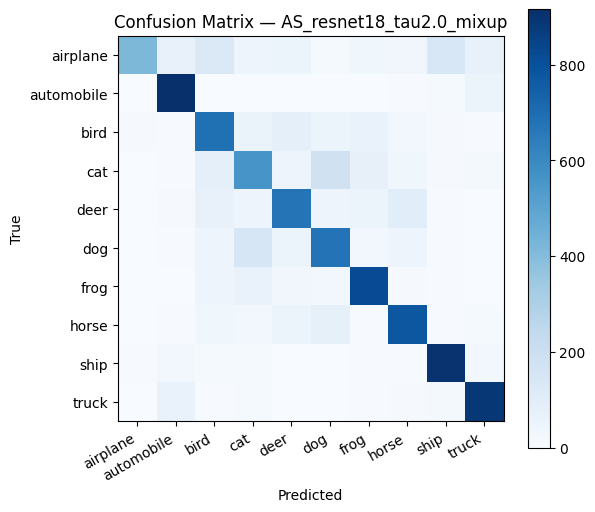

Saved: figures/cm_AS_resnet18_tau2.0_mixup.png


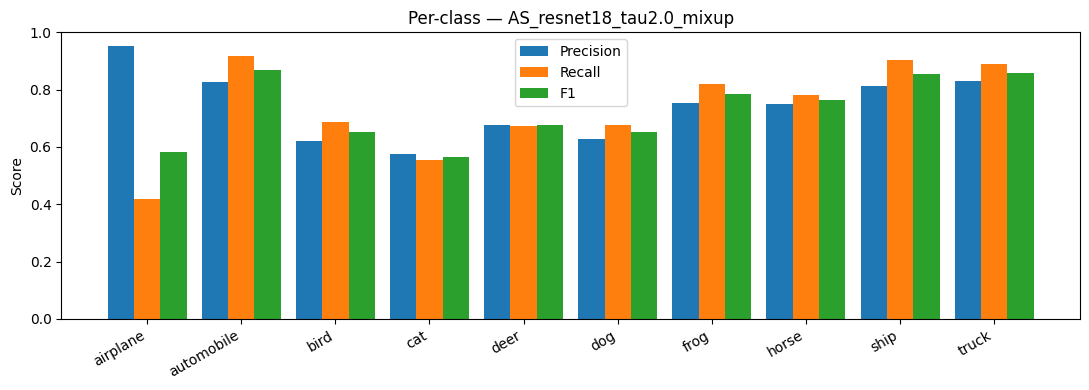

Saved: figures/perclass_AS_resnet18_tau2.0_mixup.png

AS | densenet121 | tau=2.0 | aug=mixup
Ep 01 | train_loss=1.847 acc=9.3% | val_loss=3.588 acc=22.1%
Ep 05 | train_loss=1.270 acc=14.5% | val_loss=1.783 acc=41.6%
Ep 10 | train_loss=1.078 acc=19.1% | val_loss=1.641 acc=47.8%
Ep 15 | train_loss=0.928 acc=25.4% | val_loss=1.402 acc=54.1%
Ep 20 | train_loss=0.806 acc=28.2% | val_loss=1.587 acc=55.0%
Ep 25 | train_loss=0.702 acc=35.9% | val_loss=1.179 acc=62.7%
Ep 30 | train_loss=0.509 acc=40.6% | val_loss=0.951 acc=68.2%
Ep 35 | train_loss=0.536 acc=44.3% | val_loss=0.866 acc=70.5%
Ep 40 | train_loss=0.396 acc=44.6% | val_loss=0.867 acc=75.0%
Ep 45 | train_loss=0.344 acc=52.3% | val_loss=0.780 acc=77.0%
Ep 50 | train_loss=0.351 acc=51.5% | val_loss=0.783 acc=78.2%
Final test — Acc 78.30% | Macro-F1 78.10% | Balanced Acc 78.30%

--- Classification report: AS_densenet121_tau2.0_mixup ---
              precision    recall  f1-score   support

    airplane       0.88      0.77      0.82    

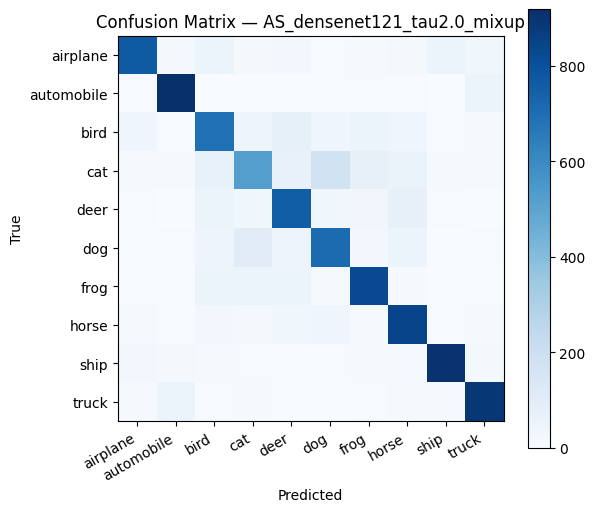

Saved: figures/cm_AS_densenet121_tau2.0_mixup.png


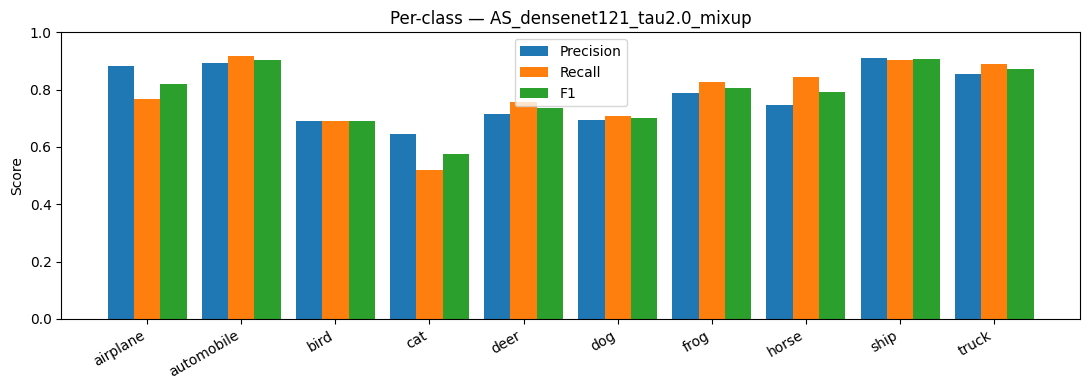

Saved: figures/perclass_AS_densenet121_tau2.0_mixup.png

--- Augmentation: CUTMIX ---

AS | resnet18 | tau=2.0 | aug=cutmix
Ep 01 | train_loss=2.359 acc=8.4% | val_loss=2.454 acc=16.9%
Ep 05 | train_loss=1.521 acc=10.7% | val_loss=2.029 acc=27.5%
Ep 10 | train_loss=1.419 acc=14.1% | val_loss=2.053 acc=35.9%
Ep 15 | train_loss=1.384 acc=15.9% | val_loss=1.911 acc=38.1%
Ep 20 | train_loss=1.264 acc=19.6% | val_loss=1.661 acc=43.6%
Ep 25 | train_loss=1.192 acc=23.5% | val_loss=1.521 acc=48.9%
Ep 30 | train_loss=1.159 acc=26.0% | val_loss=1.274 acc=53.5%
Ep 35 | train_loss=1.091 acc=28.1% | val_loss=1.027 acc=60.1%
Ep 40 | train_loss=1.008 acc=31.7% | val_loss=1.175 acc=60.9%
Ep 45 | train_loss=0.977 acc=31.3% | val_loss=0.942 acc=65.8%
Ep 50 | train_loss=0.927 acc=35.1% | val_loss=0.894 acc=67.4%
Final test — Acc 67.38% | Macro-F1 65.69% | Balanced Acc 67.38%

--- Classification report: AS_resnet18_tau2.0_cutmix ---
              precision    recall  f1-score   support

    airplane      

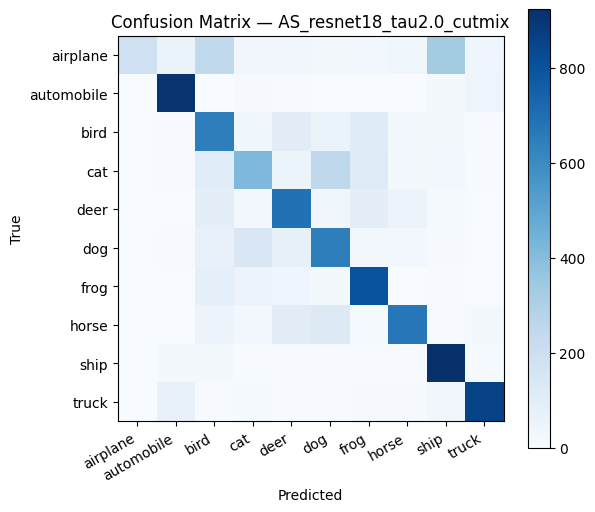

Saved: figures/cm_AS_resnet18_tau2.0_cutmix.png


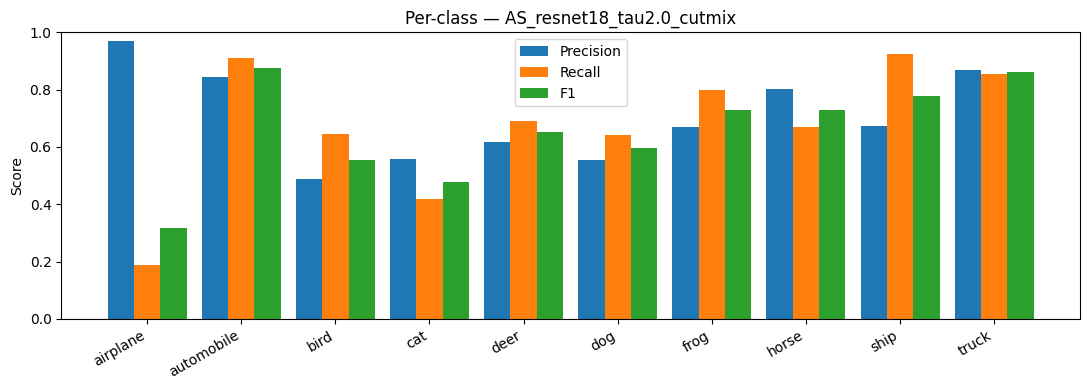

Saved: figures/perclass_AS_resnet18_tau2.0_cutmix.png

AS | densenet121 | tau=2.0 | aug=cutmix
Ep 01 | train_loss=1.930 acc=9.6% | val_loss=600.389 acc=10.9%
Ep 05 | train_loss=1.461 acc=13.5% | val_loss=1.904 acc=34.4%
Ep 10 | train_loss=1.393 acc=15.8% | val_loss=1.659 acc=39.7%
Ep 15 | train_loss=1.264 acc=19.9% | val_loss=1.673 acc=46.8%
Ep 20 | train_loss=1.170 acc=23.9% | val_loss=1.505 acc=53.8%
Ep 25 | train_loss=1.146 acc=25.7% | val_loss=1.409 acc=56.5%
Ep 30 | train_loss=1.020 acc=31.8% | val_loss=1.084 acc=62.0%
Ep 35 | train_loss=1.017 acc=32.0% | val_loss=1.071 acc=67.0%
Ep 40 | train_loss=0.900 acc=38.0% | val_loss=0.875 acc=69.2%
Ep 45 | train_loss=0.842 acc=40.5% | val_loss=0.884 acc=71.5%
Ep 50 | train_loss=0.782 acc=44.0% | val_loss=0.837 acc=72.8%
Final test — Acc 72.81% | Macro-F1 72.17% | Balanced Acc 72.81%

--- Classification report: AS_densenet121_tau2.0_cutmix ---
              precision    recall  f1-score   support

    airplane       0.96      0.39      0.5

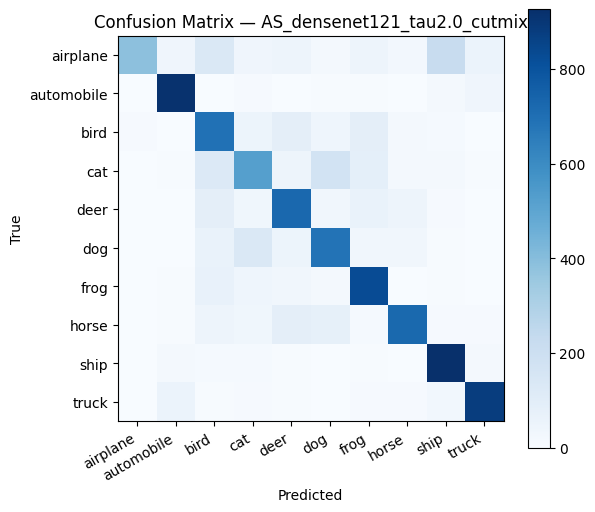

Saved: figures/cm_AS_densenet121_tau2.0_cutmix.png


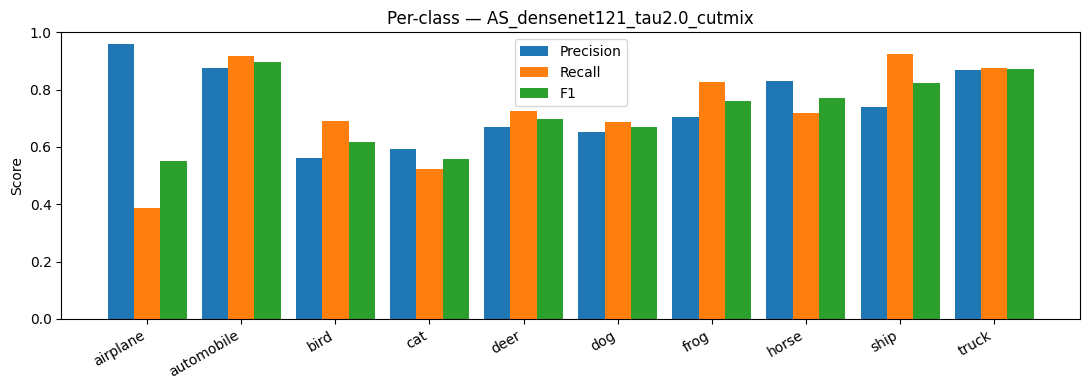

Saved: figures/perclass_AS_densenet121_tau2.0_cutmix.png

--- Augmentation: PATCHMIX ---

AS | resnet18 | tau=2.0 | aug=patchmix
Ep 01 | train_loss=2.514 acc=7.5% | val_loss=2.719 acc=15.4%
Ep 05 | train_loss=1.616 acc=9.4% | val_loss=2.161 acc=19.1%
Ep 10 | train_loss=1.567 acc=11.8% | val_loss=2.347 acc=24.7%
Ep 15 | train_loss=1.537 acc=13.1% | val_loss=2.211 acc=29.8%
Ep 20 | train_loss=1.501 acc=15.6% | val_loss=1.928 acc=39.6%
Ep 25 | train_loss=1.458 acc=17.1% | val_loss=1.676 acc=42.4%
Ep 30 | train_loss=1.417 acc=18.8% | val_loss=1.553 acc=47.4%
Ep 35 | train_loss=1.374 acc=20.9% | val_loss=1.448 acc=51.1%
Ep 40 | train_loss=1.323 acc=22.9% | val_loss=1.379 acc=56.6%
Ep 45 | train_loss=1.281 acc=24.7% | val_loss=1.168 acc=58.1%
Ep 50 | train_loss=1.269 acc=25.4% | val_loss=1.178 acc=59.0%
Final test — Acc 59.04% | Macro-F1 54.91% | Balanced Acc 59.04%

--- Classification report: AS_resnet18_tau2.0_patchmix ---
              precision    recall  f1-score   support

    airplane

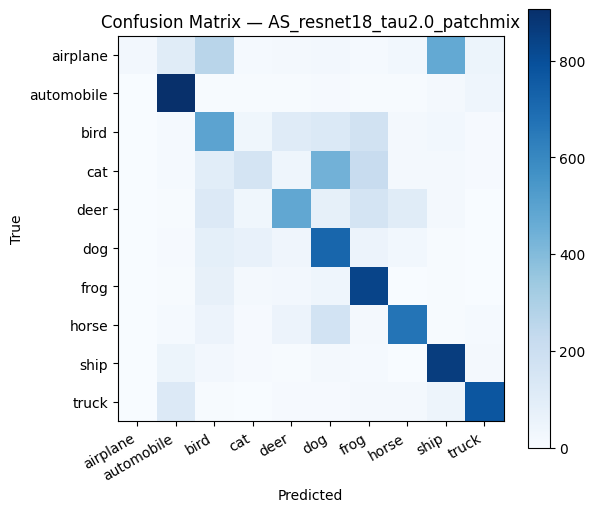

Saved: figures/cm_AS_resnet18_tau2.0_patchmix.png


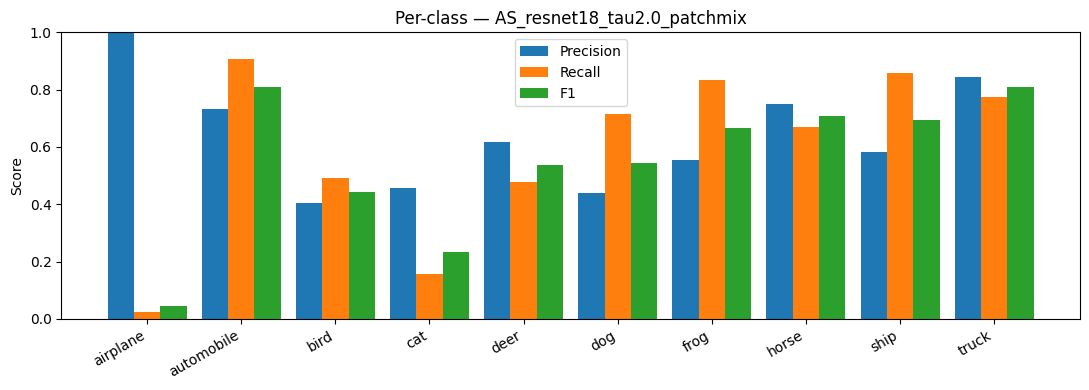

Saved: figures/perclass_AS_resnet18_tau2.0_patchmix.png

AS | densenet121 | tau=2.0 | aug=patchmix
Ep 01 | train_loss=2.006 acc=9.8% | val_loss=3.154 acc=18.1%
Ep 05 | train_loss=1.588 acc=12.2% | val_loss=2.266 acc=30.0%
Ep 10 | train_loss=1.510 acc=16.2% | val_loss=1.819 acc=39.5%
Ep 15 | train_loss=1.476 acc=17.2% | val_loss=1.718 acc=40.5%
Ep 20 | train_loss=1.421 acc=20.0% | val_loss=1.628 acc=45.3%
Ep 25 | train_loss=1.370 acc=22.0% | val_loss=1.479 acc=50.7%
Ep 30 | train_loss=1.317 acc=23.6% | val_loss=1.374 acc=52.9%
Ep 35 | train_loss=1.263 acc=25.8% | val_loss=1.229 acc=58.9%
Ep 40 | train_loss=1.192 acc=28.7% | val_loss=1.099 acc=62.4%
Ep 45 | train_loss=1.142 acc=30.9% | val_loss=1.002 acc=66.9%
Ep 50 | train_loss=1.118 acc=31.1% | val_loss=0.996 acc=67.4%
Final test — Acc 67.40% | Macro-F1 65.17% | Balanced Acc 67.40%

--- Classification report: AS_densenet121_tau2.0_patchmix ---
              precision    recall  f1-score   support

    airplane       1.00      0.13     

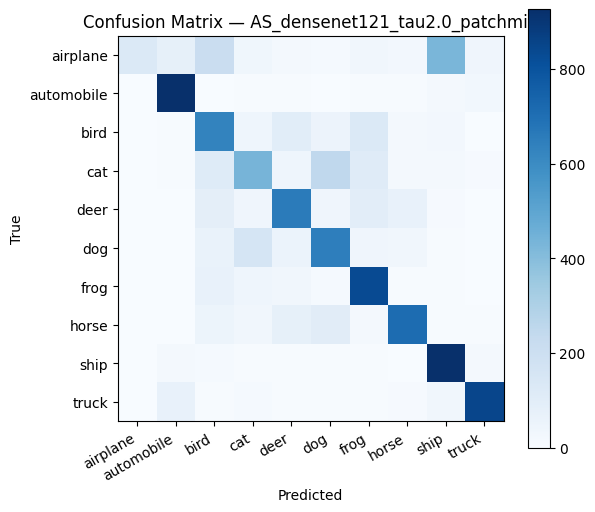

Saved: figures/cm_AS_densenet121_tau2.0_patchmix.png


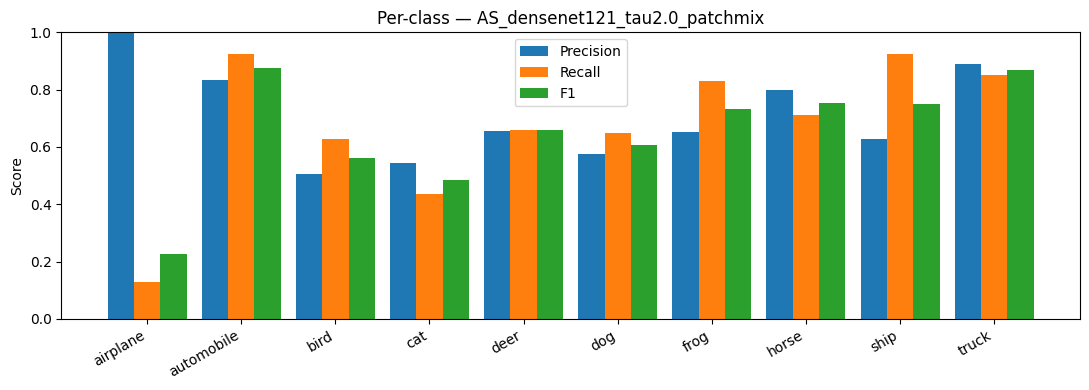

Saved: figures/perclass_AS_densenet121_tau2.0_patchmix.png


,Scenario,Model,Tau,Aug,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,0.5,cutmix,77.67,77.83,77.83
4,AS,resnet18,0.5,cutmix,76.85,76.95,76.95
3,AS,densenet121,0.5,mixup,75.68,75.76,75.76
2,AS,resnet18,0.5,mixup,74.17,74.34,74.34
1,AS,densenet121,0.5,none,74.30,74.27,74.27
0,AS,resnet18,0.5,none,74.04,74.22,74.22
7,AS,densenet121,0.5,patchmix,75.98,76.30,76.30
6,AS,resnet18,0.5,patchmix,64.19,64.92,64.92
13,AS,densenet121,1.0,cutmix,76.51,76.50,76.50
12,AS,resnet18,1.0,cutmix,71.40,71.58,71.58


Saved summary: metrics/summary_AS_tau_aug_sweep.csv


In [ ]:
# ====  Sweep taus x aug_modes x backbones; save reports, figs, summary ====
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd

os.makedirs("ckpts", exist_ok=True)
os.makedirs("metrics", exist_ok=True)
os.makedirs("figures", exist_ok=True)

summary_rows = []

pri_as = priors_from_counts(as_counts, K=10, device=device)

for tau in CONFIG["taus"]:
    print("\n" + "="*70)
    print(f"                 AS | Logit-Adjusted CE  (tau={tau})")
    print("="*70)

    for aug_mode in CONFIG["aug_modes"]:
        aug = flags_from_aug(aug_mode)
        print(f"\n--- Augmentation: {aug_mode.upper()} ---")

        # (Optional) show another tiny preview per aug_mode
        # preview_one_batch(train_loader_as, aug_mode,
        #                   mixup_alpha=CONFIG["mixup_alpha"],
        #                   cutmix_alpha=CONFIG["cutmix_alpha"],
        #                   patch_frac=CONFIG["patch_frac"])

        for backbone in CONFIG["backbones"]:
            print(f"\nAS | {backbone} | tau={tau} | aug={aug_mode}")

            model = make_model(backbone, 10).to(device)
            criterion = LogitAdjustedCELoss(pri_as, tau=tau)
            opt = torch.optim.SGD(model.parameters(), lr=CONFIG["lr"], momentum=0.9, weight_decay=5e-4)
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs"])

            best_val = -1.0; best_state = None
            history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

            for ep in range(1, CONFIG["epochs"]+1):
                tl, ta = train_one_epoch_lace(
                    model, train_loader_as, criterion, opt,
                    use_mixup=aug["use_mixup"],
                    use_cutmix=aug["use_cutmix"],
                    use_patchmix=aug["use_patchmix"],
                    mixup_alpha=CONFIG["mixup_alpha"],
                    cutmix_alpha=CONFIG["cutmix_alpha"],
                    patch_frac=CONFIG["patch_frac"]
                )
                vl, va = evaluate_lace(model, test_loader, criterion)
                sched.step()

                history["train_loss"].append(tl); history["train_acc"].append(ta)
                history["val_loss"].append(vl);   history["val_acc"].append(va)

                if va > best_val:
                    best_val = va
                    best_state = {k: v.detach().cpu() for k,v in model.state_dict().items()}

                if ep == 1 or ep % 5 == 0:
                    print(f"Ep {ep:02d} | train_loss={tl:.3f} acc={ta*100:.1f}% | val_loss={vl:.3f} acc={va*100:.1f}%")

            # restore best, test metrics + assets
            if best_state: model.load_state_dict(best_state)

            y_true, y_pred = get_preds(model, test_loader)
            cm   = confusion_matrix(y_true, y_pred, K=10)
            acc  = (y_true == y_pred).mean()
            mF1  = macro_f1(cm)
            bAcc = balanced_acc(cm)

            print(f"Final test — Acc {acc*100:.2f}% | Macro-F1 {mF1*100:.2f}% | Balanced Acc {bAcc*100:.2f}%")

            # Save checkpoint + metrics json
            tag = f"AS_{backbone}_tau{tau}_{aug_mode}"
            ckpt_path = os.path.join("ckpts", f"{tag}.pt")
            torch.save(model.state_dict(), ckpt_path)

            metrics_obj = {
                "scenario": "AS",
                "backbone": backbone,
                "tau": float(tau),
                "aug_mode": aug_mode,
                "epochs": CONFIG["epochs"],
                "test_acc": float(acc),
                "macro_f1": float(mF1),
                "balanced_acc": float(bAcc),
                "history": history,
            }
            with open(os.path.join("metrics", f"{tag}.json"), "w") as f:
                json.dump(metrics_obj, f, indent=2)

            # Classification report (print + save)
            rep = classification_report(y_true, y_pred, target_names=class_labels, digits=2)
            print("\n--- Classification report:", tag, "---")
            print(rep)
            with open(os.path.join("metrics", f"{tag}_report.txt"), "w") as f:
                f.write(rep)

            # Confusion matrix figure
            plt.figure(figsize=(6.2,5.4))
            plt.imshow(cm, cmap="Blues", interpolation="nearest")
            plt.title(f"Confusion Matrix — {tag}")
            plt.colorbar()
            ticks = np.arange(len(class_labels))
            plt.xticks(ticks, class_labels, rotation=30, ha="right")
            plt.yticks(ticks, class_labels)
            plt.xlabel("Predicted"); plt.ylabel("True")
            plt.tight_layout()
            fig_cm = os.path.join("figures", f"cm_{tag}.png")
            plt.savefig(fig_cm, dpi=180); plt.show()
            print("Saved:", fig_cm)

            # Per-class bars
            prec, rec, f1, sup = precision_recall_fscore_support(
                y_true, y_pred, labels=range(10), zero_division=0
            )
            x = np.arange(len(class_labels)); w = 0.28
            plt.figure(figsize=(11,4))
            plt.bar(x-w, prec, width=w, label='Precision')
            plt.bar(x,   rec,  width=w, label='Recall')
            plt.bar(x+w, f1,   width=w, label='F1')
            plt.ylim(0,1.0); plt.legend()
            plt.xticks(x, class_labels, rotation=30, ha='right')
            plt.ylabel("Score"); plt.title(f"Per-class — {tag}")
            plt.tight_layout()
            fig_pc = os.path.join("figures", f"perclass_{tag}.png")
            plt.savefig(fig_pc, dpi=180); plt.show()
            print("Saved:", fig_pc)

            summary_rows.append(["AS", backbone, tau, aug_mode,
                                 round(mF1*100,2), round(bAcc*100,2), round(acc*100,2)])

# Save summary table
cols = ["Scenario","Model","Tau","Aug","Macro-F1 (%)","Balanced Acc (%)","Overall Acc (%)"]
df = pd.DataFrame(summary_rows, columns=cols).sort_values(["Tau","Aug","Model"])
display(df)
summary_csv = os.path.join("metrics", "summary_AS_tau_aug_sweep.csv")
df.to_csv(summary_csv, index=False)
print("Saved summary:", summary_csv)
